# Progression-Free Survival(PFS) Analysis

In [22]:
# Mount Google drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Load the libraries and data set

In [ ]:
# Step 1: Load required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Step 2: Load your dataset
df = pd.read_csv ('/content/drive/MyDrive/PhD Project AI codes/Master_with PSA change date_preprocess_prostate_cancer_data.csv')

In [ ]:
# Step 3: Convert variables to categorical type
df['Y_FV'] = df['Y_FV'].astype('category')
df['Gleason_1']= df['Gleason_1'].astype('category')
df['Gleason_2']= df['Gleason_2'].astype('category')
df['Gleason_c']= df['Gleason_c'].astype('category')
df['Relapse']= df['Relapse'].astype('category')
df['ECOG'] = df['ECOG'].astype('category')

# Describe the dataset

In [ ]:
df.describe()

,height,weight,bmi,Prot_V,ALT,AST,Ca,Cl,Cr,K,...,MCV,Baso,Eosino,Mono,Neutro,Age_T,PSA_R_change,PSA_AF,PFS_days,PFS_event
count,265.000000,478.000000,265.000000,42.000000,440.000000,443.000000,336.000000,447.000000,449.000000,436.000000,...,461.000000,451.000000,461.000000,453.000000,460.000000,478.000000,415.000000,416.000000,478.000000,478.000000
mean,142.286792,68.994351,24.766755,51.178571,26.850000,28.108352,2.581637,105.111857,94.258797,4.603211,...,88.696529,0.044568,0.268764,0.588521,4.433478,72.096234,0.229590,43.291058,423.642259,0.094142
std,51.147481,15.990524,7.823963,20.763424,23.175182,33.880039,5.497146,3.602567,65.583166,6.470427,...,8.036297,0.059892,0.289415,0.297334,1.933189,9.228474,2.267521,164.635678,629.447063,0.292332
min,15.500000,0.000000,2.390000,20.000000,5.000000,11.000000,1.650000,76.000000,4.200000,3.000000,...,0.100000,0.000000,0.000000,0.200000,1.200000,46.000000,-33.140000,0.000000,-2833.000000,0.000000
25%,154.500000,61.900000,23.340000,36.000000,14.000000,18.000000,2.190000,103.000000,74.000000,4.000000,...,86.000000,0.000000,0.100000,0.400000,3.200000,66.000000,0.025000,0.077500,63.250000,0.000000
50%,162.000000,69.950000,25.750000,46.250000,21.000000,22.000000,2.300000,105.000000,85.000000,4.300000,...,89.000000,0.000000,0.200000,0.500000,4.050000,72.000000,0.910000,0.545000,212.000000,0.000000
75%,167.500000,77.500000,28.250000,60.000000,31.000000,27.000000,2.390000,107.000000,99.000000,4.600000,...,93.000000,0.100000,0.300000,0.700000,5.400000,79.000000,0.990000,4.837500,628.000000,0.000000
max,188.100000,124.000000,42.910000,107.000000,187.000000,510.000000,103.000000,113.000000,1233.000000,139.000000,...,111.000000,0.600000,2.200000,5.000000,15.400000,95.000000,1.000000,2001.000000,5471.000000,1.000000


In [ ]:
df.columns

Index(['ID', 'FV', 'Y_FV', 'Survival', 'DOE', 'height', 'weight', 'bmi',
       'bmi_category', 'Race', 'Marital', 'DOR_N', 'NGS_Tested', 'NGS_R',
       'NGS_R.1', 'Fam_H', 'DM', 'HT_D', 'Hrt_D', 'HLD', 'Gout', 'Hep', 'BPH',
       'CKD', 'Smoke', 'Gleason_c', 'Gleason_1', 'Gleason_2', 'Tc',
       'Tumor_Type', 'DOS', 'PaC_S', 'ECOG', 'DOT_S', 'DOT_F',
       'Rx_Description_Brand', 'Rx_C_D', 'Rx_C_D_Merged', 'SE', 'Rx_O',
       'T_place', 'Prot_V', 'Relapse', 'ALT', 'AST', 'Ca', 'Cl', 'Cr', 'K',
       'Na', 'Ur', 'PO4', 'PSA', 'RBC', 'WBC', 'Plat', 'ESR', 'Hb', 'MCH',
       'MCHC', 'MCV', 'Baso', 'Eosino', 'Mono', 'Neutro', 'Stage',
       'Risk_Group', 'Gleason_Group', 'Age_Group', 'Age_T', 'Age_T_Group',
       'Stage_Merged', 'Risk_Group_Merged', 'PSA_R_change', 'PSA_AF_Date',
       'PSA_AF', 'PSA_R_cat', 'PFS_days', 'PFS_event'],
      dtype='object')

#2. Progression-Free Survival (PFS)

PFS defined based on Biochemical (PSA) progression was defined using PCWG-style criteria,

If the PSA level goes down after treatment (this lowest point is called the PSA nadir), the cancer is considered to be getting worse (progressing) only if the PSA later:
*   increases by at least 25%, and
*   rises by at least 2.0 ng/mL above the lowest PSA level,
and this rise is confirmed again at least 3 weeks later to make sure it is not a temporary fluctuation.

If the PSA level never goes down after treatment, progression is defined as:
*  a 25% or greater increase, and
*   an increase of at least 2.0 ng/mL above the PSA level at the start of treatment,

For the current definition we skip the scan for progression only focus on PSA level
If scans (such as CT or bone scans) or worsening symptoms show cancer progression before the PSA criteria are met, that earlier finding is used to define progression.

*   Death from any cause is also counted as a progression event.

In [ ]:
import pandas as pd
import numpy as np

# Ensure datetime
date_cols = ['FV', 'PSA_AF_Date', 'DOE', 'DOT_S', 'DOT_F']
for c in date_cols:
    df[c] = pd.to_datetime(df[c], errors='coerce')

# Sort properly
df = df.sort_values(['ID', 'DOT_S', 'PSA_AF_Date','FV'])

/tmp/ipython-input-3141208466.py:7: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df[c] = pd.to_datetime(df[c], errors='coerce')
/tmp/ipython-input-3141208466.py:7: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df[c] = pd.to_datetime(df[c], errors='coerce')
/tmp/ipython-input-3141208466.py:7: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df[c] = pd.to_datetime(df[c], errors='coerce')


In [ ]:
def calculate_psa_progression_per_treatment(tdf):
    """
    Robust PSA progression logic per treatment episode
    """

    tdf = tdf.sort_values('PSA_AF_Date')

    treatment_start = tdf['DOT_S'].iloc[0]

    # ---- BASELINE PSA (robust selection) ----
    baseline_candidates = tdf.loc[
        tdf['PSA_AF_Date'] <= treatment_start, 'PSA'
    ].dropna()

    if not baseline_candidates.empty:
        baseline_psa = baseline_candidates.iloc[-1]  # closest before treatment
    else:
        # fallback: first PSA after treatment start
        baseline_candidates = tdf.loc[
            tdf['PSA_AF_Date'] > treatment_start, 'PSA_AF'
        ].dropna()
        if baseline_candidates.empty:
            return pd.NaT, 0  # cannot assess PSA progression
        baseline_psa = baseline_candidates.iloc[0]

    # ---- PSA SERIES AFTER TREATMENT ----
    psa_series = tdf[['PSA_AF_Date', 'PSA_AF']].dropna()
    psa_series = psa_series[psa_series['PSA_AF_Date'] >= treatment_start]

    if psa_series.shape[0] < 2:
        return pd.NaT, 0

    # ---- NADIR ----
    nadir_idx = psa_series['PSA_AF'].idxmin()
    nadir_psa = psa_series.loc[nadir_idx, 'PSA_AF']
    nadir_date = psa_series.loc[nadir_idx, 'PSA_AF_Date']

    # ---- CASE 1: PSA DECLINE ----
    if nadir_psa < baseline_psa:
        threshold = max(nadir_psa * 1.25, nadir_psa + 2.0)
        candidates = psa_series[
            (psa_series['PSA_AF'] >= threshold) &
            (psa_series['PSA_AF_Date'] > nadir_date)
        ]

    # ---- CASE 2: NO PSA DECLINE ----
    else:
        threshold = max(baseline_psa * 1.25, baseline_psa + 2.0)
        min_date = treatment_start + pd.Timedelta(weeks=12)
        candidates = psa_series[
            (psa_series['PSA_AF'] >= threshold) &
            (psa_series['PSA_AF_Date'] >= min_date)
        ]

    if candidates.empty:
        return pd.NaT, 0

    # ---- CONFIRMATION ≥3 WEEKS ----
    for _, row in candidates.iterrows():
        confirm = psa_series[
            (psa_series['PSA_AF_Date'] >= row['PSA_AF_Date'] + pd.Timedelta(weeks=3)) &
            (psa_series['PSA_AF'] >= threshold)
        ]
        if not confirm.empty:
            return row['PSA_AF_Date'], 1

    return pd.NaT, 0

In [ ]:
results = []

group_cols = ['ID', 'DOT_S', 'Rx_C_D_Merged']  # treatment identifier

for keys, g in df.groupby(group_cols):
    pid, t_start, tx = keys

    prog_date, prog_event = calculate_psa_progression_per_treatment(g)
    death_date = g['DOE'].iloc[0]

    # Earliest event
    event_date = min(
        [d for d in [prog_date, death_date] if pd.notna(d)],
        default=pd.NaT
    )

    censor_date = g['DOT_F'].iloc[0]
    if pd.isna(censor_date):
        censor_date = g['PSA_AF_Date'].max()

    if pd.notna(event_date):
        pfs_time = (event_date - t_start).days
        pfs_event = 1
    else:
        pfs_time = (censor_date - t_start).days
        pfs_event = 0

    results.append({
        'ID': pid,
        'Treatment': tx,
        'Treatment_Start': t_start,
        'PFS_days': pfs_time,
        'PFS_event': pfs_event,
        'PSA_Progression_Date': prog_date,
        'Death_Date': death_date
    })

pfs_treatment_df = pd.DataFrame(results)
pfs_treatment_df['Rx_C_D_Merged'] = pfs_treatment_df['Treatment'].astype(str)

In [ ]:
# PFS_time_days → time-to-event
# PFS_event → 1 = progression or death, 0 = censored

pfs_treatment_df.head()

,ID,Treatment,Treatment_Start,PFS_days,PFS_event,PSA_Progression_Date,Death_Date,Rx_C_D_Merged
0,P001,ADT Monotherapy,2022-09-21,365,0,NaT,NaT,ADT Monotherapy
1,P001,Local Therapy,2023-01-16,612,0,NaT,NaT,Local Therapy
2,P002,ADT Monotherapy,2020-03-05,245,0,NaT,NaT,ADT Monotherapy
3,P002,ARPI based Hormonal/Targeted Combination Therapy,2020-03-05,1,0,NaT,NaT,ARPI based Hormonal/Targeted Combination Therapy
4,P002,Local Therapy,2020-03-06,255,0,NaT,NaT,Local Therapy


In [ ]:
print(len(pfs_treatment_df))

475


In [ ]:
df_merged = df.merge(pfs_treatment_df[['ID', 'Rx_C_D_Merged', 'PFS_days', 'PFS_event']],
               on=['ID', 'Rx_C_D_Merged'],
               how='left')

print("Merged DataFrame head:")
display(df.head())

Merged DataFrame head:


,ID,FV,Y_FV,Survival,DOE,height,weight,bmi,bmi_category,Race,...,Age_T,Age_T_Group,Stage_Merged,Risk_Group_Merged,PSA_R_change,PSA_AF_Date,PSA_AF,PSA_R_cat,PFS_days,PFS_event
0,P001,2022-05-09,2022,Alive,NaT,NaN,43.6,NaN,Unknown,Malay,...,78,71-80,Stage IV,Metastasis,0.97,2023-03-15,0.54,≥50% response,365,0
1,P001,2022-05-09,2022,Alive,NaT,NaN,43.6,NaN,Unknown,Malay,...,79,71-80,Stage IV,Metastasis,0.98,2023-06-06,0.31,≥50% response,365,0
2,P001,2022-05-09,2022,Alive,NaT,NaN,43.6,NaN,Unknown,Malay,...,78,71-80,Stage IV,Metastasis,0.77,2023-03-15,0.54,≥50% response,612,0
3,P002,NaT,2020,Alive,NaT,NaN,66.7,NaN,Unknown,Malay,...,66,61-70,Stage IV,Metastasis,0.54,2020-09-28,63.00,≥50% response,245,0
4,P002,NaT,2020,Alive,NaT,NaN,66.7,NaN,Unknown,Malay,...,67,61-70,Stage IV,Metastasis,0.54,2020-09-28,63.00,≥50% response,1,0


In [ ]:
import os

output_folder = '/content/drive/MyDrive/PhD Project AI codes/Output_PFS'
os.makedirs(output_folder, exist_ok=True)

output_file_path = os.path.join(output_folder, 'df_merged.csv')
pfs_treatment_df.to_csv(output_file_path, index=False)

print(f"pfs_treatment_df saved to: {output_file_path}")

pfs_treatment_df saved to: /content/drive/MyDrive/PhD Project AI codes/Output_PFS/df_merged.csv


In [ ]:
df = pd.read_csv ('/content/drive/MyDrive/PhD Project AI codes/Master_with PSA change date_preprocess_prostate_cancer_data.csv')
# Convert variables to categorical type
df['Y_FV'] = df['Y_FV'].astype('category')
df['Gleason_1']= df['Gleason_1'].astype('category')
df['Gleason_2']= df['Gleason_2'].astype('category')
df['Gleason_c']= df['Gleason_c'].astype('category')
df['Relapse']= df['Relapse'].astype('category')
df['ECOG'] = df['ECOG'].astype('category')

In [ ]:
df.columns

Index(['ID', 'FV', 'Y_FV', 'Survival', 'DOE', 'height', 'weight', 'bmi',
       'bmi_category', 'Race', 'Marital', 'DOR_N', 'NGS_Tested', 'NGS_R',
       'NGS_R.1', 'Fam_H', 'DM', 'HT_D', 'Hrt_D', 'HLD', 'Gout', 'Hep', 'BPH',
       'CKD', 'Smoke', 'Gleason_c', 'Gleason_1', 'Gleason_2', 'Tc',
       'Tumor_Type', 'DOS', 'PaC_S', 'ECOG', 'DOT_S', 'DOT_F',
       'Rx_Description_Brand', 'Rx_C_D', 'Rx_C_D_Merged', 'SE', 'Rx_O',
       'T_place', 'Prot_V', 'Relapse', 'ALT', 'AST', 'Ca', 'Cl', 'Cr', 'K',
       'Na', 'Ur', 'PO4', 'PSA', 'RBC', 'WBC', 'Plat', 'ESR', 'Hb', 'MCH',
       'MCHC', 'MCV', 'Baso', 'Eosino', 'Mono', 'Neutro', 'Stage',
       'Risk_Group', 'Gleason_Group', 'Age_Group', 'Age_T', 'Age_T_Group',
       'Stage_Merged', 'Risk_Group_Merged', 'PSA_R_change', 'PSA_AF_Date',
       'PSA_AF', 'PSA_R_cat', 'PFS_days', 'PFS_event'],
      dtype='object')

## Perform Univariate Analysis for Categorical Variables

### Subtask:
For each categorical variable, calculate counts and percentages for both 'PFS event' and 'PFS without event' groups, and perform a Fisher test to determine the p-value comparing the groups. Handle missing values appropriately for the statistical tests.


In [ ]:
# Initialize these lists
numerical_cols_selected = ['height', 'weight', 'bmi', 'ALT', 'AST', 'Ca', 'Cl', 'Cr', 'K',
    'Na', 'PO4', 'PSA', 'RBC', 'WBC', 'Plat', 'Hb', 'MCH', 'PSA_AF',
    'MCHC', 'MCV', 'Baso', 'Eosino', 'Mono', 'Neutro']
categorical_cols_selected = [    'Y_FV', 'Race', 'Marital', 'Fam_H', 'DM', 'HT_D', 'Hrt_D', 'HLD',
    'Gout', 'Hep', 'BPH', 'CKD', 'Smoke', 'Tumor_Type',
    'Rx_C_D_Merged', 'T_place', 'Relapse', 'Stage_Merged',
    'Gleason_Group', 'Age_T_Group', 'PFS_event']

for col in df.columns:
    if pd.api.types.is_numeric_dtype(df[col].dtype):
        numerical_cols_selected.append(col)
    elif df[col].dtype == 'category' or df[col].dtype == 'object':
        categorical_cols_selected.append(col)

print("Numerical columns in the selected DataFrame:")
print(numerical_cols_selected)

print("\nCategorical columns in the selected DataFrame:")
print(categorical_cols_selected)

Numerical columns in the selected DataFrame:
['height', 'weight', 'bmi', 'ALT', 'AST', 'Ca', 'Cl', 'Cr', 'K', 'Na', 'PO4', 'PSA', 'RBC', 'WBC', 'Plat', 'Hb', 'MCH', 'PSA_AF', 'MCHC', 'MCV', 'Baso', 'Eosino', 'Mono', 'Neutro', 'height', 'weight', 'bmi', 'Prot_V', 'ALT', 'AST', 'Ca', 'Cl', 'Cr', 'K', 'Na', 'Ur', 'PO4', 'PSA', 'RBC', 'WBC', 'Plat', 'ESR', 'Hb', 'MCH', 'MCHC', 'MCV', 'Baso', 'Eosino', 'Mono', 'Neutro', 'Age_T', 'PSA_R_change', 'PSA_AF', 'PFS_days', 'PFS_event']

Categorical columns in the selected DataFrame:
['Y_FV', 'Race', 'Marital', 'Fam_H', 'DM', 'HT_D', 'Hrt_D', 'HLD', 'Gout', 'Hep', 'BPH', 'CKD', 'Smoke', 'Tumor_Type', 'Rx_C_D_Merged', 'T_place', 'Relapse', 'Stage_Merged', 'Gleason_Group', 'Age_T_Group', 'PFS_event', 'ID', 'FV', 'Y_FV', 'Survival', 'DOE', 'bmi_category', 'Race', 'Marital', 'DOR_N', 'NGS_Tested', 'NGS_R', 'NGS_R.1', 'Fam_H', 'DM', 'HT_D', 'Hrt_D', 'HLD', 'Gout', 'Hep', 'BPH', 'CKD', 'Smoke', 'Gleason_c', 'Gleason_1', 'Gleason_2', 'Tc', 'Tumor_Type', '

In [ ]:
from scipy.stats import chi2_contingency, mannwhitneyu
import numpy as np
import pandas as pd

# Remove Survival from the list of categorical columns to be analyzed against the treatment groups
categorical_cols_to_analyze = [col for col in categorical_cols_selected if col != 'PFS_event']

# Dictionary to store results
univariate_results = {}

# Analyze categorical variables
for col in categorical_cols_to_analyze:
    # Calculate frequency counts and percentages
    contingency_table = pd.crosstab(df[col], df['PFS_event'])

    # Only proceed if the contingency table is not empty and has more than 1 row/column for chi2_contingency
    if not contingency_table.empty and contingency_table.shape[0] > 1 and contingency_table.shape[1] > 1:
        # Perform Chi-squared test
        # chi2_contingency returns: chi2, p-value, degrees of freedom, expected frequencies
        chi2, p, dof, expected = chi2_contingency(contingency_table)
    else:
        p = np.nan # Not enough data for a meaningful test

    counts = contingency_table.stack().reset_index(name='Count')
    percentages = contingency_table.apply(lambda r: r/r.sum(), axis=1).stack().reset_index(name='Percentage')
    percentages['Percentage'] = percentages['Percentage'] * 100 # Convert to percentage

    # Store results
    univariate_results[col] = {
        'type': 'categorical',
        'counts': counts,
        'percentages': percentages,
        'p_value': p
    }

# Analyze numerical variables
for col in numerical_cols_selected:
    # Calculate mean and standard deviation for each group
    grouped_stats = df.groupby('PFS_event')[col].agg(['mean', 'std']).reset_index()

    # Prepare groups for Mann-Whitney U test
    group_alive = df[df['PFS_event'] == 1][col].dropna()
    group_passed = df[df['PFS_event'] == 0][col].dropna()

    p_value = np.nan # Default p-value

    # Perform Mann-Whitney U test if both groups have sufficient data
    if len(group_alive) >= 2 and len(group_passed) >= 2:
        stat, p_value = mannwhitneyu(group_alive, group_passed, alternative='two-sided')

    # Store results
    univariate_results[col] = {
        'type': 'numerical',
        'stats': grouped_stats,
        'p_value': p_value
    }

# Display a summary of the results structure (optional, for verification)
print("Summary of univariate analysis results:")
for col, data in univariate_results.items():
    print(f"- {col}: Type - {data['type']}, P-value - {data['p_value']:.4f}")

Summary of univariate analysis results:
- Y_FV: Type - categorical, P-value - 0.0000
- Race: Type - categorical, P-value - 0.3437
- Marital: Type - categorical, P-value - 1.0000
- Fam_H: Type - categorical, P-value - 0.1271
- DM: Type - categorical, P-value - 0.3412
- HT_D: Type - categorical, P-value - 0.2269
- Hrt_D: Type - categorical, P-value - 0.1702
- HLD: Type - categorical, P-value - 0.5893
- Gout: Type - categorical, P-value - 0.0906
- Hep: Type - categorical, P-value - 0.8630
- BPH: Type - categorical, P-value - 0.8046
- CKD: Type - categorical, P-value - 0.9283
- Smoke: Type - categorical, P-value - 0.6433
- Tumor_Type: Type - categorical, P-value - 0.8091
- Rx_C_D_Merged: Type - categorical, P-value - 0.0000
- T_place: Type - categorical, P-value - 0.3157
- Relapse: Type - categorical, P-value - 0.4487
- Stage_Merged: Type - categorical, P-value - 0.0006
- Gleason_Group: Type - categorical, P-value - 0.0291
- Age_T_Group: Type - categorical, P-value - 0.0620
- ID: Type - ca

In [ ]:
# Initialize a list to hold table rows
table_rows = []

# Get the unique treatment groups for column headers
PFS = df['PFS_event'].unique().tolist()
# Convert all elements to string before sorting
PFS_groups = [str(group) for group in PFS]
PFS_groups.sort() # Sort for consistent column order

# Add a row for the overall column headers
header_row = {'Variable': 'Variable'}
for group in PFS_groups:
    header_row[group] = group
header_row['Overall'] = 'Overall'
header_row['P-value'] = 'P-value'
table_rows.append(header_row)

# Add a row for the statistics headers
stats_header_row = {'Variable': 'Statistic'}
for group in PFS_groups:
    stats_header_row[group] = 'Count (%)' # Placeholder, will be adjusted for numerical
stats_header_row['Overall'] = 'Count' # Placeholder, will be adjusted
stats_header_row['P-value'] = ''
table_rows.append(stats_header_row)


# Iterate through the univariate analysis results
for col, data in univariate_results.items():
    variable_name = col
    p_value = data['p_value']

    if data['type'] == 'categorical':
        # Add a row for the variable name
        variable_row = {'Variable': variable_name}
        for group in PFS_groups:
            variable_row[group] = '' # Empty for the variable row
        variable_row['Overall'] = ''
        variable_row['P-value'] = f"{p_value:.4f}" if pd.notna(p_value) else ""
        table_rows.append(variable_row)

        # Add rows for each category
        counts_df = data['counts']
        percentages_df = data['percentages']

        # Get overall counts and percentages for the categorical variable
        overall_counts = df[col].value_counts()
        overall_percentages = df[col].value_counts(normalize=True) * 100

        # Iterate over the categories in the overall_counts Series
        for category, overall_count in overall_counts.items():
            overall_percentage = overall_percentages.get(category, 0)

            category_row = {'Variable': f"  {category}"} # Indent categories
            for group in PFS_groups:
                # Find the count and percentage for this category in this group
                group_count_row = counts_df[(counts_df[col] == category) & (counts_df['PFS_event'].astype(str) == group)]
                group_percentage_row = percentages_df[(percentages_df[col] == category) & (percentages_df['PFS_event'].astype(str) == group)]

                count = group_count_row['Count'].iloc[0] if not group_count_row.empty else 0
                percentage = group_percentage_row['Percentage'].iloc[0] if not group_percentage_row.empty else 0

                category_row[group] = f"{int(count)} ({percentage:.1f}%)"

            category_row['Overall'] = f"{int(overall_count)} ({overall_percentage:.1f}%)"
            category_row['P-value'] = '' # P-value is on the variable row
            table_rows.append(category_row)


    elif data['type'] == 'numerical':
        # Add a row for the variable name and p-value
        variable_row = {'Variable': variable_name}
        for group in PFS_groups:
            variable_row[group] = '' # Empty for the variable row
        variable_row['Overall'] = ''
        variable_row['P-value'] = f"{p_value:.4f}" if pd.notna(p_value) else ""
        table_rows.append(variable_row)

        # Add a row for the Mean (Std)
        mean_std_row = {'Variable': '  Mean (Std)'} # Indent
        grouped_stats_df = data['stats']

        # Calculate overall mean and std for the numerical variable
        overall_mean = df[col].mean()
        overall_std = df[col].std()

        for group in PFS_groups:
            group_stats = grouped_stats_df[grouped_stats_df['PFS_event'].astype(str) == group]
            if not group_stats.empty:
                mean = group_stats['mean'].iloc[0]
                std = group_stats['std'].iloc[0]
                mean_std_row[group] = f"{mean:.2f} ({std:.2f})"
            else:
                mean_std_row[group] = "N/A" # Handle groups with no data


        mean_std_row['Overall'] = f"{overall_mean:.2f} ({overall_std:.2f})"
        mean_std_row['P-value'] = '' # P-value is on the variable row
        table_rows.append(mean_std_row)


# Convert the list of dictionaries to a DataFrame
univariate_table_df = pd.DataFrame(table_rows)

# Display the resulting table DataFrame
display(univariate_table_df)

,Variable,0,1,Overall,P-value
0,Variable,0,1,Overall,P-value
1,Statistic,Count (%),Count (%),Count,
2,Y_FV,,,,0.0000
3,2022,119 (92.2%),10 (7.8%),129 (27.0%),
4,2023,82 (100.0%),0 (0.0%),82 (17.2%),
...,...,...,...,...,...
2157,Mean (Std),0.26 (2.30),-0.13 (1.91),0.23 (2.27),
2158,PFS_days,,,,0.9403
2159,Mean (Std),418.12 (617.43),476.78 (741.06),423.64 (629.45),
2160,PFS_event,,,,0.0000


In [ ]:
# Save the dataset
import os

# Define the output directory path
output_dir = '/content/drive/MyDrive/PhD Project AI codes/Output_PFS'

# Install python-docx if not already installed
!pip install python-docx

from docx import Document

# Create a new Word document object
document = Document()

# Add a title to the document
document.add_heading('Univariate Analysis Table', 0)

# Add the DataFrame to the document as a table
# Check if univariate_table_df exists before trying to add it
if 'univariate_table_df' in locals() or 'univariate_table_df' in globals():
    table = document.add_table(rows=1, cols=len(univariate_table_df.columns))
    table.style = 'Table Grid'

    # Add header row
    hdr_cells = table.rows[0].cells
    for i, col_name in enumerate(univariate_table_df.columns):
        hdr_cells[i].text = col_name

    # Add data rows
    for index, row in univariate_table_df.iterrows():
        row_cells = table.add_row().cells
        for i, cell_value in enumerate(row):
            row_cells[i].text = str(cell_value)

    # Define the output path for the univariate table
    univariate_output_path = f"{output_dir}/univariate_analysis_table.docx"

    # Save the document to the output path
    document.save(univariate_output_path)
    print(f"Univariate analysis table saved to {univariate_output_path}")
else:
    print("Error: univariate_table_df not found. Please run the cell that generates the univariate analysis table first.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 12.8 MB/s eta 0:00:00
Univariate analysis table saved to /content/drive/MyDrive/PhD Project AI codes/Output_PFS/univariate_analysis_table.docx


In [ ]:
import pandas as pd
import numpy as np

# Define study_end_date (from original cell jDjiif0PgSdH)
study_end_date = pd.to_datetime("31/12/2024", format="%d/%m/%Y")

# 1. Ensure 'FV' and 'DOE' columns in df are datetime objects (from original cell jDjiif0PgSdH)
# The 'df' in the current environment is the one filtered by 'selected_cols'.
# So we just need to ensure the types are correct.
df['FV'] = pd.to_datetime(df['FV'], format='%d/%m/%Y', errors='coerce')
df['DOE'] = pd.to_datetime(df['DOE'], format='%d/%m/%Y', errors='coerce')

# 2. Define PFS_Event_Observed (from original cell jDjiif0PgSdH)
# Assuming 'PFS_event' column is already in df from previous merges/selections
df['PFS_Event_Observed'] = df['PFS_event']

# 3. Define calculate_pfs function (from original cell jDjiif0PgSdH)
def calculate_pfs(group):
    group = group.sort_values('FV')
    start_date = group['FV'].min()

    event_rows = group[group['PFS_Event_Observed'] == 1]

    if len(event_rows) > 0:
        first_event_date = event_rows['FV'].iloc[0]
        event = 1
        end_date = first_event_date
    else:
        event = 0
        end_date = study_end_date

    time_days = (end_date - start_date).days

    return pd.Series({
        'Final_PFS_Event': event,
        'PFS_Time_years': time_days / 365.25
    })

# 4. Calculate df_pfs (from original cell jDjiif0PgSdH)
df_pfs = df.groupby('ID').apply(calculate_pfs).reset_index()

# 5. Merge back to create df_full (from original cell jDjiif0PgSdH)
df_full = df.merge(df_pfs, on='ID', how='left') # Use how='left' to preserve all rows from current df
df_full.sort_values(by=['ID', 'FV'], inplace=True)

# Now proceed with the original subtask: create df_patient_level_static
# Sort the df_full DataFrame by 'ID' and 'FV' to ensure correct 'latest' record selection
df_full_sorted = df_full.sort_values(by=['ID', 'FV']).copy()

# Group by 'ID' and select the last record for each group
df_patient_level_static = df_full_sorted.groupby('ID').tail(1).reset_index(drop=True)

print("df_patient_level_static created successfully. Displaying head:")
display(df_patient_level_static.head())

df_patient_level_static created successfully. Displaying head:


/tmp/ipython-input-2294305079.py:40: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_pfs = df.groupby('ID').apply(calculate_pfs).reset_index()


,ID,FV,Y_FV,Survival,DOE,height,weight,bmi,bmi_category,Race,...,Risk_Group_Merged,PSA_R_change,PSA_AF_Date,PSA_AF,PSA_R_cat,PFS_days,PFS_event,PFS_Event_Observed,Final_PFS_Event,PFS_Time_years
0,P001,2022-09-05,2022,Alive,NaT,NaN,43.6,NaN,Unknown,Malay,...,Metastasis,0.77,15/03/2023,0.54,≥50% response,612,0,0,0.0,2.321697
1,P002,2020-02-19,2020,Passed Away,2021-06-04,NaN,66.7,NaN,Unknown,Malay,...,Metastasis,-0.33,03/05/2021,747.90,PSA_increase,89,1,1,1.0,0.000000
2,P003,2018-07-19,2018,Passed Away,2020-05-25,155.3,55.0,22.80,Normal,Malay,...,Metastasis,0.49,23/07/2019,66.20,<50% response,420,1,1,1.0,0.000000
3,P005,2022-04-18,2022,Alive,NaT,NaN,49.6,NaN,Unknown,Malay,...,High Risk,0.82,28/07/2023,0.02,≥50% response,483,0,0,0.0,2.704997
4,P006,2024-09-03,2024,Alive,NaT,165.0,85.9,31.55,Obese,Malay,...,High Risk,0.76,18/12/2024,1.11,≥50% response,91,0,0,0.0,0.325804


In [ ]:
# Initialize these lists
numerical_cols_selected = ['height', 'weight', 'bmi', 'ALT', 'AST', 'Ca', 'Cl', 'Cr', 'K',
    'Na', 'PO4', 'PSA', 'RBC', 'WBC', 'Plat', 'Hb', 'MCH', 'PSA_AF',
    'MCHC', 'MCV', 'Baso', 'Eosino', 'Mono', 'Neutro']
categorical_cols_selected = [    'Y_FV', 'Race', 'Marital', 'Fam_H', 'DM', 'HT_D', 'Hrt_D', 'HLD',
    'Gout', 'Hep', 'BPH', 'CKD', 'Smoke', 'Tumor_Type',
    'Rx_C_D_Merged', 'T_place', 'Relapse', 'Stage_Merged',
    'Gleason_Group', 'Age_T_Group', 'PFS_event']

for col in df.columns:
    if pd.api.types.is_numeric_dtype(df_patient_level_static[col].dtype):
        numerical_cols_selected.append(col)
    elif df_patient_level_static[col].dtype == 'category' or df_patient_level_static[col].dtype == 'object':
        categorical_cols_selected.append(col)

print("Numerical columns in the selected DataFrame:")
print(numerical_cols_selected)

print("\nCategorical columns in the selected DataFrame:")
print(categorical_cols_selected)

Numerical columns in the selected DataFrame:
['height', 'weight', 'bmi', 'ALT', 'AST', 'Ca', 'Cl', 'Cr', 'K', 'Na', 'PO4', 'PSA', 'RBC', 'WBC', 'Plat', 'Hb', 'MCH', 'PSA_AF', 'MCHC', 'MCV', 'Baso', 'Eosino', 'Mono', 'Neutro', 'height', 'weight', 'bmi', 'Prot_V', 'ALT', 'AST', 'Ca', 'Cl', 'Cr', 'K', 'Na', 'Ur', 'PO4', 'PSA', 'RBC', 'WBC', 'Plat', 'ESR', 'Hb', 'MCH', 'MCHC', 'MCV', 'Baso', 'Eosino', 'Mono', 'Neutro', 'Age_T', 'PSA_R_change', 'PSA_AF', 'PFS_days', 'PFS_event', 'PFS_Event_Observed']

Categorical columns in the selected DataFrame:
['Y_FV', 'Race', 'Marital', 'Fam_H', 'DM', 'HT_D', 'Hrt_D', 'HLD', 'Gout', 'Hep', 'BPH', 'CKD', 'Smoke', 'Tumor_Type', 'Rx_C_D_Merged', 'T_place', 'Relapse', 'Stage_Merged', 'Gleason_Group', 'Age_T_Group', 'PFS_event', 'ID', 'Y_FV', 'Survival', 'bmi_category', 'Race', 'Marital', 'DOR_N', 'NGS_Tested', 'NGS_R', 'NGS_R.1', 'Fam_H', 'DM', 'HT_D', 'Hrt_D', 'HLD', 'Gout', 'Hep', 'BPH', 'CKD', 'Smoke', 'Gleason_c', 'Gleason_1', 'Gleason_2', 'Tc', 'Tumor

In [ ]:
from scipy.stats import chi2_contingency, mannwhitneyu
import numpy as np
import pandas as pd

# Remove Survival from the list of categorical columns to be analyzed against the treatment groups
categorical_cols_to_analyze = [col for col in categorical_cols_selected if col != 'PFS_event']

# Dictionary to store results
univariate_results = {}

# Analyze categorical variables
for col in categorical_cols_to_analyze:
    # Calculate frequency counts and percentages
    contingency_table = pd.crosstab(df_patient_level_static[col], df_patient_level_static['PFS_event'])

    # Only proceed if the contingency table is not empty and has more than 1 row/column for chi2_contingency
    if not contingency_table.empty and contingency_table.shape[0] > 1 and contingency_table.shape[1] > 1:
        # Perform Chi-squared test
        # chi2_contingency returns: chi2, p-value, degrees of freedom, expected frequencies
        chi2, p, dof, expected = chi2_contingency(contingency_table)
    else:
        p = np.nan # Not enough data for a meaningful test

    counts = contingency_table.stack().reset_index(name='Count')
    percentages = contingency_table.apply(lambda r: r/r.sum(), axis=1).stack().reset_index(name='Percentage')
    percentages['Percentage'] = percentages['Percentage'] * 100 # Convert to percentage

    # Store results
    univariate_results[col] = {
        'type': 'categorical',
        'counts': counts,
        'percentages': percentages,
        'p_value': p
    }

# Analyze numerical variables
for col in numerical_cols_selected:
    # Calculate mean and standard deviation for each group
    grouped_stats = df.groupby('PFS_event')[col].agg(['mean', 'std']).reset_index()

    # Prepare groups for Mann-Whitney U test
    group_alive = df_patient_level_static[df_patient_level_static['PFS_event'] == 1][col].dropna()
    group_passed = df_patient_level_static[df_patient_level_static['PFS_event'] == 0][col].dropna()

    p_value = np.nan # Default p-value

    # Perform Mann-Whitney U test if both groups have sufficient data
    if len(group_alive) >= 2 and len(group_passed) >= 2:
        stat, p_value = mannwhitneyu(group_alive, group_passed, alternative='two-sided')

    # Store results
    univariate_results[col] = {
        'type': 'numerical',
        'stats': grouped_stats,
        'p_value': p_value
    }

# Display a summary of the results structure (optional, for verification)
print("Summary of univariate analysis results:")
for col, data in univariate_results.items():
    print(f"- {col}: Type - {data['type']}, P-value - {data['p_value']:.4f}")

Summary of univariate analysis results:
- Y_FV: Type - categorical, P-value - 0.0000
- Race: Type - categorical, P-value - 0.5576
- Marital: Type - categorical, P-value - 1.0000
- Fam_H: Type - categorical, P-value - 0.2475
- DM: Type - categorical, P-value - 0.2158
- HT_D: Type - categorical, P-value - 0.2734
- Hrt_D: Type - categorical, P-value - 0.2694
- HLD: Type - categorical, P-value - 0.7603
- Gout: Type - categorical, P-value - 0.0854
- Hep: Type - categorical, P-value - 1.0000
- BPH: Type - categorical, P-value - 0.7985
- CKD: Type - categorical, P-value - 0.7985
- Smoke: Type - categorical, P-value - 0.6951
- Tumor_Type: Type - categorical, P-value - 0.4223
- Rx_C_D_Merged: Type - categorical, P-value - 0.0001
- T_place: Type - categorical, P-value - 0.0133
- Relapse: Type - categorical, P-value - 0.5368
- Stage_Merged: Type - categorical, P-value - 0.0006
- Gleason_Group: Type - categorical, P-value - 0.0034
- Age_T_Group: Type - categorical, P-value - 0.3623
- ID: Type - ca

In [ ]:
# Initialize a list to hold table rows
table_rows = []

# Get the unique treatment groups for column headers
PFS = df_patient_level_static['PFS_event'].unique().tolist()
# Convert all elements to string before sorting
PFS_groups = [str(group) for group in PFS]
PFS_groups.sort() # Sort for consistent column order

# Add a row for the overall column headers
header_row = {'Variable': 'Variable'}
for group in PFS_groups:
    header_row[group] = group
header_row['Overall'] = 'Overall'
header_row['P-value'] = 'P-value'
table_rows.append(header_row)

# Add a row for the statistics headers
stats_header_row = {'Variable': 'Statistic'}
for group in PFS_groups:
    stats_header_row[group] = 'Count (%)' # Placeholder, will be adjusted for numerical
stats_header_row['Overall'] = 'Count' # Placeholder, will be adjusted
stats_header_row['P-value'] = ''
table_rows.append(stats_header_row)


# Iterate through the univariate analysis results
for col, data in univariate_results.items():
    variable_name = col
    p_value = data['p_value']

    if data['type'] == 'categorical':
        # Add a row for the variable name
        variable_row = {'Variable': variable_name}
        for group in PFS_groups:
            variable_row[group] = '' # Empty for the variable row
        variable_row['Overall'] = ''
        variable_row['P-value'] = f"{p_value:.4f}" if pd.notna(p_value) else ""
        table_rows.append(variable_row)

        # Add rows for each category
        counts_df = data['counts']
        percentages_df = data['percentages']

        # Get overall counts and percentages for the categorical variable
        overall_counts = df_patient_level_static[col].value_counts()
        overall_percentages = df_patient_level_static[col].value_counts(normalize=True) * 100

        # Iterate over the categories in the overall_counts Series
        for category, overall_count in overall_counts.items():
            overall_percentage = overall_percentages.get(category, 0)

            category_row = {'Variable': f"  {category}"} # Indent categories
            for group in PFS_groups:
                # Find the count and percentage for this category in this group
                group_count_row = counts_df[(counts_df[col] == category) & (counts_df['PFS_event'].astype(str) == group)]
                group_percentage_row = percentages_df[(percentages_df[col] == category) & (percentages_df['PFS_event'].astype(str) == group)]

                count = group_count_row['Count'].iloc[0] if not group_count_row.empty else 0
                percentage = group_percentage_row['Percentage'].iloc[0] if not group_percentage_row.empty else 0

                category_row[group] = f"{int(count)} ({percentage:.1f}%)"

            category_row['Overall'] = f"{int(overall_count)} ({overall_percentage:.1f}%)"
            category_row['P-value'] = '' # P-value is on the variable row
            table_rows.append(category_row)


    elif data['type'] == 'numerical':
        # Add a row for the variable name and p-value
        variable_row = {'Variable': variable_name}
        for group in PFS_groups:
            variable_row[group] = '' # Empty for the variable row
        variable_row['Overall'] = ''
        variable_row['P-value'] = f"{p_value:.4f}" if pd.notna(p_value) else ""
        table_rows.append(variable_row)

        # Add a row for the Mean (Std)
        mean_std_row = {'Variable': '  Mean (Std)'} # Indent
        grouped_stats_df = data['stats']

        # Calculate overall mean and std for the numerical variable
        overall_mean = df_patient_level_static[col].mean()
        overall_std = df_patient_level_static[col].std()

        for group in PFS_groups:
            group_stats = grouped_stats_df[grouped_stats_df['PFS_event'].astype(str) == group]
            if not group_stats.empty:
                mean = group_stats['mean'].iloc[0]
                std = group_stats['std'].iloc[0]
                mean_std_row[group] = f"{mean:.2f} ({std:.2f})"
            else:
                mean_std_row[group] = "N/A" # Handle groups with no data


        mean_std_row['Overall'] = f"{overall_mean:.2f} ({overall_std:.2f})"
        mean_std_row['P-value'] = '' # P-value is on the variable row
        table_rows.append(mean_std_row)


# Convert the list of dictionaries to a DataFrame
univariate_table_df = pd.DataFrame(table_rows)

# Display the resulting table DataFrame
display(univariate_table_df)

,Variable,0,1,Overall,P-value
0,Variable,0,1,Overall,P-value
1,Statistic,Count (%),Count (%),Count,
2,Y_FV,,,,0.0000
3,2022,48 (82.8%),10 (17.2%),58 (27.4%),
4,2023,38 (100.0%),0 (0.0%),38 (17.9%),
...,...,...,...,...,...
1279,Mean (Std),418.12 (617.43),476.78 (741.06),526.02 (603.36),
1280,PFS_event,,,,0.0000
1281,Mean (Std),0.00 (0.00),1.00 (0.00),0.19 (0.40),
1282,PFS_Event_Observed,,,,0.0000


In [ ]:
# Save the dataset
import os

# Define the output directory path
output_dir = '/content/drive/MyDrive/PhD Project AI codes/Output_PFS'

# Install python-docx if not already installed
!pip install python-docx

from docx import Document

# Create a new Word document object
document = Document()

# Add a title to the document
document.add_heading('Univariate Analysis Table (Patient-Level Static Data)', 0)

# Add the DataFrame to the document as a table
# Check if univariate_table_df exists before trying to add it
if 'univariate_table_df' in locals() or 'univariate_table_df' in globals():
    table = document.add_table(rows=1, cols=len(univariate_table_df.columns))
    table.style = 'Table Grid'

    # Add header row
    hdr_cells = table.rows[0].cells
    for i, col_name in enumerate(univariate_table_df.columns):
        hdr_cells[i].text = col_name

    # Add data rows
    for index, row in univariate_table_df.iterrows():
        row_cells = table.add_row().cells
        for i, cell_value in enumerate(row):
            row_cells[i].text = str(cell_value)

    # Define the output path for the univariate table
    univariate_output_path = f"{output_dir}/univariate_analysis_table_df_patient_level_static.docx"

    # Save the document to the output path
    document.save(univariate_output_path)
    print(f"Univariate analysis table saved to {univariate_output_path}")
else:
    print("Error: univariate_table_df not found. Please run the cell that generates the univariate analysis table first.")

Univariate analysis table saved to /content/drive/MyDrive/PhD Project AI codes/Output_PFS/univariate_analysis_table_df_patient_level_static.docx


# Install required packages

In [23]:
# Install required packages
!pip install scikit-learn
!pip install fancyimpute
!pip install pycox torchtuples lifelines
!pip install torchtuples
!pip install shap
!pip install matplotlib seaborn
!pip install scikit-survival

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv ('/content/drive/MyDrive/PhD Project AI codes/Master_with PSA change date_preprocess_prostate_cancer_data.csv')
# Convert variables to categorical type
df['Y_FV'] = df['Y_FV'].astype('category')
df['Gleason_1']= df['Gleason_1'].astype('category')
df['Gleason_2']= df['Gleason_2'].astype('category')
df['Gleason_c']= df['Gleason_c'].astype('category')
df['Relapse']= df['Relapse'].astype('category')
df['ECOG'] = df['ECOG'].astype('category')

In [25]:
print("Counts for PFS_event:")
display(df.PFS_event.value_counts())

print("\nPercentages for PFS_event:")
display(df.PFS_event.value_counts(normalize=True) * 100)

Counts for PFS_event:


,count
PFS_event,
0,433
1,45



Percentages for PFS_event:


,proportion
PFS_event,
0,90.585774
1,9.414226


# Data Preprocessing, Data Splitting and Recurrent Autoencoder

In [46]:
# PACKAGE INSTALLATION
import sys
if 'sksurv' not in sys.modules:
    !pip install scikit-survival

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from fancyimpute import IterativeImputer
from sklearn.ensemble import ExtraTreesRegressor


# DATE HANDLING
df = df.copy()

df['FV'] = pd.to_datetime(df['FV'], errors='coerce')
df['DOE'] = pd.to_datetime(df['DOE'], errors='coerce')
df['DOT_S'] = pd.to_datetime(df['DOT_S'], errors='coerce')
df['PSA_AF_Date'] = pd.to_datetime(df['PSA_AF_Date'], errors='coerce')

study_end_date = pd.to_datetime("2024-12-31")



# DEFINE PFS EVENT (ASSUMED PRE-COMPUTED)

# Ensure binary and non-missing
df['PFS_Event_Observed'] = df['PFS_event'].fillna(0).astype(int)



#  FEATURE DEFINITIONS

numerical_features = [
    'height', 'weight', 'bmi', 'ALT', 'AST', 'Ca', 'Cl', 'Cr', 'K',
    'Na', 'PO4', 'RBC', 'WBC', 'Plat', 'Hb', 'MCH',
    'MCHC', 'MCV', 'Baso', 'Eosino', 'Mono', 'Neutro'
]

categorical_features = [
    'Race', 'Marital', 'Fam_H', 'DM', 'HT_D', 'Hrt_D', 'HLD',
    'Gout', 'Hep', 'BPH', 'CKD', 'Smoke', 'Tumor_Type',
    'Rx_C_D_Merged', 'T_place', 'Relapse', 'Stage_Merged',
    'Gleason_Group', 'Age_T_Group'
]



#  TRAIN–TEST SPLIT (BY ID)

id_event_table = (
    df.groupby('ID')['PFS_Event_Observed']
    .max()
    .reset_index()
)

unique_ids = id_event_table['ID'].values
stratify_targets = id_event_table['PFS_Event_Observed'].values

ID_train, ID_test = train_test_split(
    unique_ids,
    test_size=0.2,
    random_state=42,
    stratify=stratify_targets
)

print(f"Total Unique IDs: {len(unique_ids)}")
print(f"Train IDs: {len(ID_train)}, Test IDs: {len(ID_test)}")

df_train = df[df['ID'].isin(ID_train)].copy()
df_test = df[df['ID'].isin(ID_test)].copy()


y_train_final = df_train['PFS_Event_Observed'].values
y_test_final = df_test['PFS_Event_Observed'].values


#  IMPUTATION & ENCODING

imputer = IterativeImputer(
    estimator=ExtraTreesRegressor(n_estimators=100, random_state=42),
    max_iter=10,
    random_state=42
)

scaler = StandardScaler()
categorical_encoders = {}

# Numerical
df_train[numerical_features] = imputer.fit_transform(df_train[numerical_features])
df_train[numerical_features] = scaler.fit_transform(df_train[numerical_features])

df_test[numerical_features] = imputer.transform(df_test[numerical_features])
df_test[numerical_features] = scaler.transform(df_test[numerical_features])

# Categorical
for col in categorical_features:
    le = LabelEncoder()
    df_train[col] = le.fit_transform(df_train[col].astype(str).fillna("missing"))
    categorical_encoders[col] = le

for col in categorical_features:
    le = categorical_encoders[col]
    df_test[col] = df_test[col].apply(
        lambda x: le.transform([str(x)])[0]
        if str(x) in le.classes_
        else len(le.classes_)
    )

feature_cols_processed = numerical_features + categorical_features
NUM_FEATURES = len(feature_cols_processed)



# SEQUENCE CREATION

def create_sequences(df_data, feature_cols):
    sequences, ids = [], []

    for pid, group in df_data.groupby('ID'):
        if group.shape[0] == 0:
            continue
        seq = group.sort_values('FV')[feature_cols].values.astype(np.float32)
        sequences.append(seq)
        ids.append(pid)

    max_len = max(len(seq) for seq in sequences)

    padded = np.zeros(
        (len(sequences), max_len, len(feature_cols)),
        dtype=np.float32
    )

    for i, seq in enumerate(sequences):
        padded[i, :len(seq), :] = seq

    return torch.tensor(padded), ids, max_len


X_train_seq, ID_train_for_embeddings, _ = create_sequences(df_train, feature_cols_processed)
X_test_seq, ID_test_for_embeddings, _ = create_sequences(df_test, feature_cols_processed)



#  RECURRENT AUTOENCODER

class RAE(nn.Module):
    def __init__(self, input_size, hidden_size, embedding_dim):
        super().__init__()
        self.encoder = nn.LSTM(input_size, hidden_size, batch_first=True)
        self.h_to_z = nn.Linear(hidden_size, embedding_dim)
        self.z_to_h = nn.Linear(embedding_dim, hidden_size)
        self.decoder = nn.LSTM(input_size, hidden_size, batch_first=True)
        self.out = nn.Linear(hidden_size, input_size)

    def forward(self, x):
        _, (h, _) = self.encoder(x)
        z = self.h_to_z(h[-1])
        h0 = self.z_to_h(z).unsqueeze(0)
        c0 = torch.zeros_like(h0)
        dec_out, _ = self.decoder(x, (h0, c0))
        return self.out(dec_out), z



# RAE TRAINING

rae = RAE(NUM_FEATURES, hidden_size=128, embedding_dim=32)
optimizer = torch.optim.Adam(rae.parameters(), lr=0.001)
criterion = nn.MSELoss()

loader = DataLoader(X_train_seq, batch_size=32, shuffle=True)

for epoch in range(100):
    rae.train()
    epoch_loss = 0
    for batch in loader:
        optimizer.zero_grad()
        recon, _ = rae(batch)
        mask = (batch != 0).float()
        loss = criterion(recon * mask, batch * mask)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

print("RAE training complete.")



# EMBEDDING EXTRACTION

rae.eval()

def extract_embeddings(X):
    embeddings = []
    with torch.no_grad():
        for seq in X:
            _, z = rae(seq.unsqueeze(0))
            embeddings.append(z.squeeze().numpy())
    return np.array(embeddings)

X_train_emb = extract_embeddings(X_train_seq)
X_test_emb = extract_embeddings(X_test_seq)

print("Train embeddings:", X_train_emb.shape)
print("Test embeddings:", X_test_emb.shape)


Total Unique IDs: 212
Train IDs: 169, Test IDs: 43


/usr/local/lib/python3.12/dist-packages/sklearn/impute/_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


RAE training complete.
Train embeddings: (169, 32)
Test embeddings: (43, 32)


In [113]:
# save the train embedding X_train_emb,X_test_emb y_train_final,y_test_final
# Define the output folder on Google Drive
output_folder = '/content/drive/MyDrive/PhD Project AI codes/Output_PFS'

# Create the directory if it doesn't exist
import os
os.makedirs(output_folder, exist_ok=True)

# Full path for the file
output_path = os.path.join(output_folder, 'train_test_embeddings.npz')

# Save the compressed file
# NOTE: y_train_final and y_test_final are defined in cell ez0Gvwc7KTjr.
# Ensure that cell is executed before this one to avoid NameError.
np.savez_compressed(output_path,
                    X_train_emb=X_train_emb,
                    X_test_emb=X_test_emb,
                    y_train_final=y_train_final,
                    y_test_final=y_test_final)

print(f"Train/test embeddings and labels successfully saved to:\n{output_path}")

Train/test embeddings and labels successfully saved to:
/content/drive/MyDrive/PhD Project AI codes/Output_PFS/train_test_embeddings.npz


# Fit CoxPH, Random Survival Forest, Gradient Boosting Survival

In [77]:
# IMPORTS
import numpy as np
import pandas as pd
import torch
from sksurv.ensemble import RandomSurvivalForest, GradientBoostingSurvivalAnalysis
from sksurv.linear_model import CoxPHSurvivalAnalysis



# STEP 1: PFS CALCULATION (TRAIN & TEST)
def apply_pfs(df, study_end_date):
    df = df.copy()

    df["PFS_End_Date"] = np.where(
        df["PFS_Event_Observed"] == 1,
        df["DOE"],              # progression / death
        study_end_date          # censored
    )

    df["PFS_End_Date"] = pd.to_datetime(df["PFS_End_Date"], errors="coerce")
    df["DOT_S"] = pd.to_datetime(df["DOT_S"], errors="coerce")

    df["PFS_Time_years"] = (
        (df["PFS_End_Date"] - df["DOT_S"]).dt.days / 365.25
    )

    # Remove invalid survival times
    df = df[df["PFS_Time_years"].notna() & (df["PFS_Time_years"] > 0)]

    return df


df_train_processed = apply_pfs(df_train, study_end_date)
df_test_processed  = apply_pfs(df_test, study_end_date)



# STEP 2: CREATE SEQUENCES (RETURNS IDS — CRITICAL FIX)
def create_sequences(df, feature_cols):
    sequences = []
    ids = []

    for pid, group in df.groupby("ID"):
        group = group.sort_values("FV")

        if group.shape[0] == 0:
            continue

        seq = group[feature_cols].values.astype(np.float32)
        sequences.append(seq)
        ids.append(pid)

    max_len = max(len(seq) for seq in sequences)

    padded = np.zeros(
        (len(sequences), max_len, len(feature_cols)),
        dtype=np.float32
    )

    for i, seq in enumerate(sequences):
        padded[i, :len(seq), :] = seq

    return torch.tensor(padded), ids


X_train_seq, ID_train_emb = create_sequences(df_train_processed, feature_cols_processed)
X_test_seq,  ID_test_emb  = create_sequences(df_test_processed, feature_cols_processed)


# STEP 3: EXTRACT EMBEDDINGS
X_train_emb = extract_embeddings(X_train_seq)   # shape: (n_train_ids, d)
X_test_emb  = extract_embeddings(X_test_seq)

assert X_train_emb.shape[0] == len(ID_train_emb)
assert X_test_emb.shape[0]  == len(ID_test_emb)



# STEP 4: BUILD ID-LEVEL SURVIVAL TABLE
def build_survival_table(df):
    return (
        df.groupby("ID")
        .agg(
            Final_PFS_Event=("PFS_Event_Observed", "max"),
            PFS_Time_years=("PFS_Time_years", "max")
        )
    )


y_train_survival = build_survival_table(df_train_processed)
y_test_survival  = build_survival_table(df_test_processed)



# STEP 5: ALIGN EMBEDDINGS WITH SURVIVAL TARGETS (KEY STEP)

df_X_train_emb = pd.DataFrame(X_train_emb, index=ID_train_emb)
df_X_test_emb  = pd.DataFrame(X_test_emb, index=ID_test_emb)

merged_train = y_train_survival.join(df_X_train_emb, how="inner")
merged_test  = y_test_survival.join(df_X_test_emb, how="inner")

# Final feature matrices
X_train_final = merged_train.iloc[:, 2:].values
X_test_final  = merged_test.iloc[:, 2:].values

# Structured survival arrays (scikit-survival format)
y_train_final = np.array(
    [(bool(e), float(t)) for e, t in zip(
        merged_train["Final_PFS_Event"],
        merged_train["PFS_Time_years"]
    )],
    dtype=[("event", "bool"), ("time", "float")]
)

y_test_final = np.array(
    [(bool(e), float(t)) for e, t in zip(
        merged_test["Final_PFS_Event"],
        merged_test["PFS_Time_years"]
    )],
    dtype=[("event", "bool"), ("time", "float")]
)


# STEP 6: TRAIN SURVIVAL MODELS

# ---- COX PH ----
cox = CoxPHSurvivalAnalysis(alpha=0.1)
cox.fit(X_train_final, y_train_final)

# ---- RANDOM SURVIVAL FOREST ----
rsf = RandomSurvivalForest(
    n_estimators=300,
    min_samples_split=20,
    max_depth=5,
    random_state=42,
    n_jobs=-1
)
rsf.fit(X_train_final, y_train_final)


# ---- GRADIENT BOOSTING SURVIVAL ----
gbr = GradientBoostingSurvivalAnalysis(
    learning_rate=0.1,
    n_estimators=200,
    max_depth=7,
    random_state=42
)
gbr.fit(X_train_final, y_train_final)


GradientBoostingSurvivalAnalysis(max_depth=7, n_estimators=200, random_state=42)

# DeepSurv (pycox) — Full network, training, and saving

In [70]:
import pandas as pd
import numpy as np
import torch
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from pycox.models import CoxPH
from pycox.evaluation import EvalSurv
import torchtuples as tt

in_features = X_train_emb.shape[1]

net = tt.practical.MLPVanilla(
    in_features=in_features,
    num_nodes=[128,64,32],     # hidden layers
    out_features=1,         # required for CoxPH
    activation=torch.nn.ReLU,
    dropout=0.2,
    output_bias=False
)

model = CoxPH(net, tt.optim.Adam)
model.optimizer.set_lr(0.01)

import torch
import torchtuples as tt
import numpy as np # Import numpy if not already in scope, for np.float32 and np.int64

# Convert X_train_processed and X_test_processed to PyTorch tensors (float32)
X_train_tensor = torch.from_numpy(X_train_emb).float()
X_test_tensor = torch.from_numpy(X_test_emb).float()

# Prepare the 'y' data for pycox. DeepSurv expects a tuple (time, event)
# y_train_structured and y_test_structured are already numpy structured arrays
# with 'event' (bool) and 'time' (float). We need to extract them and ensure float32.

# Corrected get_target function to work with structured NumPy arrays and convert to PyTorch tensors
get_target = lambda y_struct_array: (
    torch.from_numpy(y_struct_array['time'].astype(np.float32)),
    torch.from_numpy(y_struct_array['event'].astype(np.int64))
)

y_train_pycox = get_target(y_train_final)
y_test_pycox = get_target(y_test_final)

# Wrap the data using `tt.tuplefy`
train = tt.tuplefy(X_train_tensor, y_train_pycox)
test = tt.tuplefy(X_test_tensor, y_test_pycox)

print("Data successfully converted to PyTorch tensors and pycox-compatible format.")
print(f"X_train_tensor shape: {X_train_tensor.shape}")
print(f"y_train_pycox types: time={y_train_pycox[0].dtype}, event={y_train_pycox[1].dtype}")

batch_size = 256
epochs = 100

log = model.fit(
    X_train_tensor, y_train_pycox, # Pass tensors directly
    batch_size=batch_size,
    epochs=epochs,
    verbose=True,
    val_data=(X_test_tensor, y_test_pycox) # Pass test tensors directly
)

Data successfully converted to PyTorch tensors and pycox-compatible format.
X_train_tensor shape: torch.Size([160, 32])
y_train_pycox types: time=torch.float32, event=torch.int64
0:	[0s / 0s],		train_loss: 4.8805,	val_loss: 2.2449
1:	[0s / 0s],		train_loss: 4.5868,	val_loss: 2.2598
2:	[0s / 0s],		train_loss: 4.0934,	val_loss: 2.2795
3:	[0s / 0s],		train_loss: 3.7366,	val_loss: 2.3248
4:	[0s / 0s],		train_loss: 3.8484,	val_loss: 2.3325
5:	[0s / 0s],		train_loss: 3.6997,	val_loss: 2.3519
6:	[0s / 0s],		train_loss: 3.6224,	val_loss: 2.3489
7:	[0s / 0s],		train_loss: 3.5123,	val_loss: 2.3554
8:	[0s / 0s],		train_loss: 3.5731,	val_loss: 2.3614
9:	[0s / 0s],		train_loss: 3.4229,	val_loss: 2.3680
10:	[0s / 0s],		train_loss: 3.5180,	val_loss: 2.3870
11:	[0s / 0s],		train_loss: 3.5787,	val_loss: 2.3933
12:	[0s / 0s],		train_loss: 3.4765,	val_loss: 2.3903
13:	[0s / 0s],		train_loss: 3.4262,	val_loss: 2.4062
14:	[0s / 0s],		train_loss: 3.7077,	val_loss: 2.4183
15:	[0s / 0s],		train_loss: 3.4791,	

In [71]:
# First, compute the baseline hazards. This is required before predicting survival functions.
model.compute_baseline_hazards()

surv = model.predict_surv_df(X_test_tensor)
surv.head()

import scipy.integrate

# The import error should be resolved by restarting runtime and upgrading pycox.
# If this cell is run after restart and pycox upgrade, the monkey patch should not be strictly necessary
# but is kept as a safeguard in case of lingering environment issues.

# Monkey patch for SciPy 1.14+ if pycox still tries to use 'simps' due to module caching
# (though pycox 0.3.2+ should use 'simpson' directly).
if not hasattr(scipy.integrate, "simps"):
    if hasattr(scipy.integrate, "simpson"):
        scipy.integrate.simps = scipy.integrate.simpson
    elif hasattr(scipy.integrate, "trapezoid"):
        scipy.integrate.simps = scipy.integrate.trapezoid
    else:
        print("Warning: Neither scipy.integrate.simps, simpson nor trapezoid found. Evaluation might fail.")

from pycox.evaluation import EvalSurv

ev = EvalSurv(
    surv,
    y_test_final['time'],
    y_test_final['event'].astype(bool),
    censor_surv='km'
)

# C-index
c_index = ev.concordance_td('antolini')
print("C-index:", c_index)

# Integrated Brier Score
times = np.linspace(y_test_final['time'].min(),
                    y_test_final['time'].max(),
                    100)

ibs = ev.integrated_brier_score(times)
print("IBS:", ibs)

C-index: 0.625
IBS: 0.12334072436818463


In [50]:
import torch
import torchtuples as tt
import numpy as np
from pycox.models import CoxPH
from pycox.evaluation import EvalSurv

# 1. Define a search space for the hyperparameters
learning_rates = [0.01, 0.001, 0.0001]
epochs_list = [50, 100, 200]
batch_sizes = [128, 256]
num_nodes_configs = [[32], [64, 32], [128, 64, 32]]
dropout_rates = [0.1, 0.2]

# 2. Initialize variables to store the best C-index, best IBS, and corresponding hyperparameters
best_c_index = -np.inf # Initialize with negative infinity for C-index (higher is better)
best_ibs = np.inf      # Initialize with infinity for IBS (lower is better)
best_hyperparams = {}

# Ensure X_train_tensor and y_train_pycox are defined globally or passed in context
# (from previous cells) as they are needed for training.
# Ensure X_test_tensor and y_test_pycox are defined for validation.

# Convert y_test_structured for EvalSurv times argument later
times_for_ibs = np.linspace(y_test_final['time'].min(), y_test_final['time'].max(), 100)

print("Starting hyperparameter tuning...")

# 3. Create a loop that iterates through all combinations of hyperparameters
for lr in learning_rates:
    for num_e in epochs_list:
        for bs in batch_sizes:
            for nn_config in num_nodes_configs:
                for dp_rate in dropout_rates:
                    print(f"\nTrying: LR={lr}, Epochs={num_e}, BatchSize={bs}, NN_Nodes={nn_config}, Dropout={dp_rate}")

                    # Set random seed for reproducibility in each trial
                    np.random.seed(42)
                    torch.manual_seed(42)

                    # 4a. Create a tt.practical.MLPVanilla neural network
                    current_net = tt.practical.MLPVanilla(
                        in_features=in_features, # in_features defined here
                        num_nodes=nn_config,
                        out_features=1,
                        activation=torch.nn.ReLU, # Changed from Relu to ReLU
                        dropout=dp_rate,
                        output_bias=False
                    )

                    # 4b. Instantiate a CoxPH model and set learning rate
                    current_model = CoxPH(current_net, tt.optim.Adam)
                    current_model.optimizer.set_lr(lr)

                    # 4c. Train the CoxPH model
                    log = current_model.fit(
                        X_train_tensor, y_train_pycox,
                        batch_size=bs,
                        epochs=num_e,
                        verbose=False, # Set to True for verbose output per epoch
                        val_data=(X_test_tensor, y_test_pycox)
                    )

                    # 4d. Compute the baseline hazards
                    current_model.compute_baseline_hazards()

                    # 4e. Predict survival probabilities for X_test_tensor
                    surv_preds = current_model.predict_surv_df(X_test_tensor)

                    # 4f. Evaluate the model's performance
                    # Prepare EvalSurv object
                    ev = EvalSurv(
                        surv_preds,
                        y_test_final['time'],
                        y_test_final['event'].astype(bool),
                        censor_surv='km'
                    )

                    # Calculate C-index
                    current_c_index = ev.concordance_td('antolini')

                    # Calculate IBS
                    current_ibs = ev.integrated_brier_score(times_for_ibs)

                    print(f"  Current C-index: {current_c_index:.4f}, Current IBS: {current_ibs:.4f}")

                    # 4g. Compare and update best metrics and hyperparameters
                    # For simplicity, let's prioritize C-index, then IBS as tie-breaker
                    if current_c_index > best_c_index:
                        best_c_index = current_c_index
                        best_ibs = current_ibs
                        best_hyperparams = {
                            'learning_rate': lr,
                            'epochs': num_e,
                            'batch_size': bs,
                            'num_nodes': nn_config,
                            'dropout_rate': dp_rate
                        }
                        print("  >> New best C-index found!")
                    elif current_c_index == best_c_index and current_ibs < best_ibs:
                        best_ibs = current_ibs
                        best_hyperparams = {
                            'learning_rate': lr,
                            'epochs': num_e,
                            'batch_size': bs,
                            'num_nodes': nn_config,
                            'dropout_rate': dp_rate
                        }
                        print("  >> Same C-index, but lower IBS found!")

# 5. Print the best hyperparameters and their corresponding C-index and IBS values
print("\n" + "="*50)
print("Hyperparameter Tuning Complete")
print("Best Hyperparameters:", best_hyperparams)
print(f"Best C-index: {best_c_index:.4f}")
print(f"Best IBS: {best_ibs:.4f}")
print("="*50)

Starting hyperparameter tuning...

Trying: LR=0.01, Epochs=50, BatchSize=128, NN_Nodes=[32], Dropout=0.1
  Current C-index: 0.0000, Current IBS: nan
  >> New best C-index found!

Trying: LR=0.01, Epochs=50, BatchSize=128, NN_Nodes=[32], Dropout=0.2
  Current C-index: 0.0000, Current IBS: nan

Trying: LR=0.01, Epochs=50, BatchSize=128, NN_Nodes=[64, 32], Dropout=0.1
  Current C-index: 0.0000, Current IBS: nan

Trying: LR=0.01, Epochs=50, BatchSize=128, NN_Nodes=[64, 32], Dropout=0.2
  Current C-index: 0.0000, Current IBS: nan

Trying: LR=0.01, Epochs=50, BatchSize=128, NN_Nodes=[128, 64, 32], Dropout=0.1
  Current C-index: 0.0000, Current IBS: nan

Trying: LR=0.01, Epochs=50, BatchSize=128, NN_Nodes=[128, 64, 32], Dropout=0.2
  Current C-index: 0.0000, Current IBS: nan

Trying: LR=0.01, Epochs=50, BatchSize=256, NN_Nodes=[32], Dropout=0.1
  Current C-index: 0.5000, Current IBS: 0.1164
  >> New best C-index found!

Trying: LR=0.01, Epochs=50, BatchSize=256, NN_Nodes=[32], Dropout=0.2
  C

# Obtain survival functions for each model at specified evaluation times

We will build a matrix of survival probabilities S(t | x) for each subject at a set of times to evaluate Brier/IBS/calibration/AUC via pycox.EvalSurv (which accepts a survival function DataFrame).


In [78]:
import numpy as np
import pandas as pd

# 1. BASIC VARIABLES FROM YOUR EXISTING DATA
y_test_times = np.array(y_test_final['time']).astype(float)
y_test_events = np.array(y_test_final['event']).astype(int)

# For DeepSurv / pycox
x_train_ds = X_train_tensor   # torch tensor (on CPU)
y_train_ds = y_train_pycox    # tuple (duration, event)
x_test_ds  = X_test_tensor    # torch tensor (on CPU)

# 2. DEFINE MAX EVALUATION TIME SAFELY
# Instead of unknown: min_max_domain_sksurv
# We use MAX observed follow-up time across train+test
max_eval_time = float(
    max(
        np.max(y_train_ds[0].cpu().numpy()),
        np.max(y_test_times)
    )
)

if max_eval_time <= 0:
    max_eval_time = 0.01
    print("WARNING: max_eval_time fixed to 0.01")

times = np.linspace(0.01, max_eval_time, 100)

# 3. HELPER – convert scikit-survival step functions → DataFrame
def survfuncs_to_df(surv_funcs, evaluation_times):
    S = []
    for fn in surv_funcs:
        S.append(fn(evaluation_times))
    S = np.vstack(S)
    df = pd.DataFrame(S.T, index=evaluation_times.astype('float64'))
    df.index.name = "timeline"
    return df


# 4. COX (scikit-survival)
cox_surv_funcs = cox.predict_survival_function(X_test_emb)
cox_surv_df = survfuncs_to_df(cox_surv_funcs, times)


# 5. RANDOM SURVIVAL FOREST (scikit-survival)
rsf_surv_funcs = rsf.predict_survival_function(X_test_emb)
rsf_surv_df = survfuncs_to_df(rsf_surv_funcs, times)

# 6. GRADIENT BOOSTING SURVIVAL MODEL (GBT)
gbr_surv_funcs = gbr.predict_survival_function(X_test_emb)
gbr_surv_df = survfuncs_to_df(gbr_surv_funcs, times)

# 7. DEEPSURV (pycox) – FIXED!
net_model = model

# MUST compute baseline hazard using *all* training data
net_model.compute_baseline_hazards()

# Predict survival for test set
surv_deepsurv_df = net_model.predict_surv_df(x_test_ds)

# Fix for index dtype (must be float)
surv_deepsurv_df.index = surv_deepsurv_df.index.astype('float64')

# Interpolate to match "times"
deepsurv_surv_df = (
    surv_deepsurv_df
      .reindex(surv_deepsurv_df.index.union(times))
      .interpolate()
      .reindex(times.astype('float64'))
)
deepsurv_surv_df.index.name = "timeline"

print("=== All survival curves generated successfully ===")

=== All survival curves generated successfully ===


# Evaluation: C-index, time-dependent AUC, Brier, IBS, Calibration plots

In [79]:
# Full evaluation pipeline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

from sksurv.util import Surv
from sksurv.metrics import (
    concordance_index_censored,
    cumulative_dynamic_auc,
    brier_score,
    integrated_brier_score
)
from sksurv.exceptions import NoComparablePairException  # Explicitly import the exception
from lifelines import KaplanMeierFitter


# Helper: safe conversion for DeepSurv outputs (torch tensors -> numpy)
def to_numpy_safe(x):
    """Convert possible torch tensor or pandas Series/DataFrame to 1D numpy array on CPU."""
    try:
        import torch
        if isinstance(x, torch.Tensor):
            return x.detach().cpu().numpy().reshape(-1)
    except Exception:
        pass
    # pandas objects
    if hasattr(x, "values"):
        return np.asarray(x.values).reshape(-1)
    return np.asarray(x).reshape(-1)


# 1) Risk scores for each model (ensure shape: (n_test,))
# Cox (scikit-survival) -> .predict returns risk score (higher=risk)
risk_cox = to_numpy_safe(cox.predict(X_test_emb))

# RSF (scikit-survival)
risk_rsf = to_numpy_safe(rsf.predict(X_test_emb))

# Gradient boosting survival (scikit-survival)
risk_gbr = to_numpy_safe(gbr.predict(X_test_emb))

# DeepSurv (pycox): try multiple APIs
try:
    # pycox CoxPH model: predict returns linear predictors or risk
    raw_deep = net_model.predict(x_test_ds)
    risk_deep = to_numpy_safe(raw_deep)
except Exception:
    # try alternative attribute (some wrappers use .predict_risk etc.)
    try:
        raw_deep = net_model.predict_risk(x_test_ds)
        risk_deep = to_numpy_safe(raw_deep)
    except Exception:
        # last fallback: assume net_model returns DataFrame from predict_surv_df; then compute summary risk
        try:
            surv_df = net_model.predict_surv_df(x_test_ds)  # DataFrame: index times, columns subjects
            # simple risk summary: -mean survival across times per subject
            risk_deep = -np.array(surv_df.mean(axis=0))
        except Exception as e:
            raise RuntimeError("Unable to extract DeepSurv risk scores. Inspect net_model API.") from e


# 2) Harrell C-index & bootstrap CI
def compute_cindex(pred_scores, y_struct):
    try:
        return concordance_index_censored(y_struct['event'], y_struct['time'], pred_scores)[0]
    except NoComparablePairException:
        return np.nan

def bootstrap_cindex_ci(y_times, y_events, risk, n_boot=500, seed=42, alpha=0.05):
    rng = np.random.RandomState(seed)
    n = len(y_times)
    cvals = []
    for i in range(n_boot):
        idx = rng.randint(0, n, n)
        t_i = y_times[idx]
        e_i = y_events[idx].astype(bool)
        r_i = risk[idx]
        # compute only if at least one event present
        if e_i.any():
            try: # The try block was already here
                cvals.append(concordance_index_censored(e_i, t_i, r_i)[0])
            except NoComparablePairException:
                continue
    if len(cvals) == 0:
        return (np.nan, np.nan, np.nan)
    lower = np.percentile(cvals, 100*(alpha/2))
    upper = np.percentile(cvals, 100*(1-alpha/2))
    mean = np.mean(cvals)
    return lower, upper, mean

cindex_cox  = compute_cindex(risk_cox,  y_test_final)
cindex_rsf  = compute_cindex(risk_rsf,  y_test_final)
cindex_gbr  = compute_cindex(risk_gbr,  y_test_final)
cindex_deep = compute_cindex(risk_deep, y_test_final)

ci_cox  = bootstrap_cindex_ci(y_test_times, y_test_events, risk_cox)
ci_rsf  = bootstrap_cindex_ci(y_test_times, y_test_events, risk_rsf)
ci_gbr  = bootstrap_cindex_ci(y_test_times, y_test_events, risk_gbr)
ci_deep = bootstrap_cindex_ci(y_test_times, y_test_events, risk_deep)

print("C-index (Harrell):")
print(f" Cox : {cindex_cox:.3f}  (bootstrap mean={ci_cox[2]:.3f}, 95% CI [{ci_cox[0]:.3f},{ci_cox[1]:.3f}])")
print(f" RSF : {cindex_rsf:.3f}  (bootstrap mean={ci_rsf[2]:.3f}, 95% CI [{ci_rsf[0]:.3f},{ci_rsf[1]:.3f}])")
print(f" GBT : {cindex_gbr:.3f}  (bootstrap mean={ci_gbr[2]:.3f}, 95% CI [{ci_gbr[0]:.3f},{ci_gbr[1]:.3f}])")
print(f" Deep: {cindex_deep:.3f}  (bootstrap mean={ci_deep[2]:.3f}, 95% CI [{ci_deep[0]:.3f},{ci_deep[1]:.3f}])")

# 3) Time-dependent AUC (cumulative_dynamic_auc)
# choose eval times (quartiles or clinically meaningful times)
eval_times = np.array([1, 2, 3, 4, 5])
auc_times, auc_cox = cumulative_dynamic_auc(y_train_final, y_test_final, risk_cox, eval_times)
print("\nTime-Dependent AUC (C-index):\n")
print("Cox Model AUCs:")
for t, auc in zip(eval_times, auc_times):
    print(f"  AUC at {t:.2f} years: {auc:.3f}")

eval_times = np.array([1, 2, 3, 4, 5])
auc_times, auc_rsf = cumulative_dynamic_auc(y_train_final, y_test_final, risk_rsf, eval_times)
print("\nRSF Model AUCs:")
for t, auc in zip(eval_times, auc_times):
    print(f"  AUC at {t:.2f} years: {auc:.3f}")

eval_times = np.array([1, 2, 3, 4, 5])
auc_times, auc_gbr = cumulative_dynamic_auc(y_train_final, y_test_final, risk_gbr, eval_times)
print("\nGBT Model AUCs:")
for t, auc in zip(eval_times, auc_times):
    print(f"  AUC at {t:.2f} years: {auc:.3f}")

eval_times = np.array([1, 2, 3, 4, 5])
auc_times, auc_deep = cumulative_dynamic_auc(y_train_final, y_test_final, risk_deep, eval_times)
print("\nDeepSurv Model AUCs:")
for t, auc in zip(eval_times, auc_times):
    print(f"  AUC at {t:.2f} years: {auc:.3f}")


/usr/local/lib/python3.12/dist-packages/sksurv/metrics.py:146: RuntimeWarning: invalid value encountered in scalar divide
  cindex = numerator / denominator
/usr/local/lib/python3.12/dist-packages/sksurv/metrics.py:146: RuntimeWarning: invalid value encountered in scalar divide
  cindex = numerator / denominator
/usr/local/lib/python3.12/dist-packages/sksurv/metrics.py:146: RuntimeWarning: invalid value encountered in scalar divide
  cindex = numerator / denominator
/usr/local/lib/python3.12/dist-packages/sksurv/metrics.py:146: RuntimeWarning: invalid value encountered in scalar divide
  cindex = numerator / denominator


C-index (Harrell):
 Cox : 0.438  (bootstrap mean=nan, 95% CI [nan,nan])
 RSF : 0.688  (bootstrap mean=nan, 95% CI [nan,nan])
 GBT : 0.594  (bootstrap mean=nan, 95% CI [nan,nan])
 Deep: 0.625  (bootstrap mean=nan, 95% CI [nan,nan])

Time-Dependent AUC (C-index):

Cox Model AUCs:
  AUC at 1.00 years: nan
  AUC at 2.00 years: nan
  AUC at 3.00 years: nan
  AUC at 4.00 years: 0.588
  AUC at 5.00 years: 0.500

RSF Model AUCs:
  AUC at 1.00 years: nan
  AUC at 2.00 years: nan
  AUC at 3.00 years: nan
  AUC at 4.00 years: 0.824
  AUC at 5.00 years: 0.833

GBT Model AUCs:
  AUC at 1.00 years: nan
  AUC at 2.00 years: nan
  AUC at 3.00 years: nan
  AUC at 4.00 years: 0.824
  AUC at 5.00 years: 0.917

DeepSurv Model AUCs:
  AUC at 1.00 years: nan
  AUC at 2.00 years: nan
  AUC at 3.00 years: nan
  AUC at 4.00 years: 0.824
  AUC at 5.00 years: 0.833


/usr/local/lib/python3.12/dist-packages/sksurv/metrics.py:498: RuntimeWarning: invalid value encountered in divide
  true_pos = cumsum_tp / cumsum_tp[-1]
/usr/local/lib/python3.12/dist-packages/sksurv/metrics.py:498: RuntimeWarning: invalid value encountered in divide
  true_pos = cumsum_tp / cumsum_tp[-1]
/usr/local/lib/python3.12/dist-packages/sksurv/metrics.py:498: RuntimeWarning: invalid value encountered in divide
  true_pos = cumsum_tp / cumsum_tp[-1]
/usr/local/lib/python3.12/dist-packages/sksurv/metrics.py:498: RuntimeWarning: invalid value encountered in divide
  true_pos = cumsum_tp / cumsum_tp[-1]


In [80]:
# integrated brier score
from sksurv.metrics import brier_score, integrated_brier_score

print("ROBUST TEST Brier Score (Calibration):")
# Brier score for cox
survival_functions = cox.predict_survival_function(X_test_emb)
times = times = np.array([1, 2, 3, 4, 5])
survival_probabilities = np.asarray([
    f(times) for f in survival_functions
])

times,brier_scores_cox = brier_score(y_train_final,y_test_final,survival_probabilities,times)
ibs_cox = integrated_brier_score(y_train_final, y_test_final, survival_probabilities, times)
for t, bs in zip(times, brier_scores_cox):
     print(f"Brier Scores for Cox: {bs:.4f}")
print(f"IBS for Cox: {ibs_cox:.4f}")


# Brier score for rsf
survival_functions = rsf.predict_survival_function(X_test_emb)
times = times = np.array([1, 2, 3, 4, 5])
survival_probabilities = np.asarray([
    f(times) for f in survival_functions
])
times,brier_scores_rsf = brier_score(y_train_final,y_test_final,survival_probabilities,times)
ibs_rsf = integrated_brier_score(y_train_final, y_test_final, survival_probabilities, times)
for t, bs in zip(times, brier_scores_rsf):
       print(f"Brier Scores for rsf: {bs:.4f}")
print(f"IBS for rsf: {ibs_rsf:.4f}")


# Brier score for gbr
survival_functions = gbr.predict_survival_function(X_test_emb)
times = times = np.array([1, 2, 3, 4, 5])
survival_probabilities = np.asarray([
    f(times) for f in survival_functions
])
times,brier_scores_gbr = brier_score(y_train_final,y_test_final,survival_probabilities,times)
ibs_gbr = integrated_brier_score(y_train_final, y_test_final, survival_probabilities, times)
for t, bs in zip(times, brier_scores_gbr):
     print(f"Brier Scores for gbr: {bs:.4f}")
print(f"IBS for gbr: {ibs_gbr:.4f}")

ROBUST TEST Brier Score (Calibration):
Brier Scores for Cox: 0.0001
Brier Scores for Cox: 0.0001
Brier Scores for Cox: 0.0012
Brier Scores for Cox: 0.0541
Brier Scores for Cox: 0.0614
IBS for Cox: 0.0215
Brier Scores for rsf: 0.0002
Brier Scores for rsf: 0.0002
Brier Scores for rsf: 0.0026
Brier Scores for rsf: 0.0507
Brier Scores for rsf: 0.1103
IBS for rsf: 0.0272
Brier Scores for gbr: 0.0000
Brier Scores for gbr: 0.0000
Brier Scores for gbr: 0.0002
Brier Scores for gbr: 0.0575
Brier Scores for gbr: 0.0957
IBS for gbr: 0.0264


In [81]:
!pip install python-docx
import os
import pandas as pd
import numpy as np
from docx import Document
from docx.shared import Inches

# Consolidate C-index results
c_index_data = {
    "Model": ["Cox", "RSF", "GBT", "Deep"],
    "C-index": [cindex_cox, cindex_rsf, cindex_gbr, cindex_deep],
    "C-index CI lower": [ci_cox[0], ci_rsf[0], ci_gbr[0], ci_deep[0]],
    "C-index CI upper": [ci_cox[1], ci_rsf[1], ci_gbr[1], ci_deep[1]]
}
c_index_df = pd.DataFrame(c_index_data)

# Consolidate Time-Dependent AUC results
# Ensure eval_times_for_auc is consistent and available
times = eval_times if 'eval_times_for_auc' in globals() else np.array([1, 2, 3, 4, 5])

auc_data = {
    "Time (years)": times.tolist(),
    "Cox AUC": auc_cox.tolist(),
    "RSF AUC": auc_rsf.tolist(),
    "GBT AUC": auc_gbr.tolist(),
    "DeepSurv AUC": auc_deep.tolist()
}
auc_df = pd.DataFrame(auc_data)

# Define the output folder and ensure it exists
output_folder = '/content/drive/MyDrive/PhD Project AI codes/Output_PFS'
os.makedirs(output_folder, exist_ok=True)

# Create a new Document
document = Document()
document.add_heading('Survival Model Performance Metrics', level=1)

# Add C-index table
document.add_heading('Harrell C-index', level=2)
table_c_index = document.add_table(rows=1, cols=len(c_index_df.columns))
table_c_index.style = 'Table Grid'
hdr_cells_c_index = table_c_index.rows[0].cells
for i, col in enumerate(c_index_df.columns):
    hdr_cells_c_index[i].text = col
for index, row in c_index_df.iterrows():
    row_cells = table_c_index.add_row().cells
    for i, col in enumerate(c_index_df.columns):
        row_cells[i].text = f"{row[col]:.4f}" if isinstance(row[col], (float, np.float64)) else str(row[col])

# Add Time-Dependent AUC table
document.add_heading('Time-Dependent AUC (C-index)', level=2)
table_auc = document.add_table(rows=1, cols=len(auc_df.columns))
table_auc.style = 'Table Grid'
hdr_cells_auc = table_auc.rows[0].cells
for i, col in enumerate(auc_df.columns):
    hdr_cells_auc[i].text = col
for index, row in auc_df.iterrows():
    row_cells = table_auc.add_row().cells
    for i, col in enumerate(auc_df.columns):
        row_cells[i].text = f"{row[col]:.3f}" if isinstance(row[col], (float, np.float64)) else str(row[col])


# Define the output file path
output_file_path = os.path.join(output_folder, 'PFS_Model_Cindex_AUC_Performance.docx')

# Save the document
document.save(output_file_path)

print(f"C-index and AUC tables saved to '{output_file_path}'")


C-index and AUC tables saved to '/content/drive/MyDrive/PhD Project AI codes/Output_PFS/PFS_Model_Cindex_AUC_Performance.docx'


# Figures_AUC,VIMP,

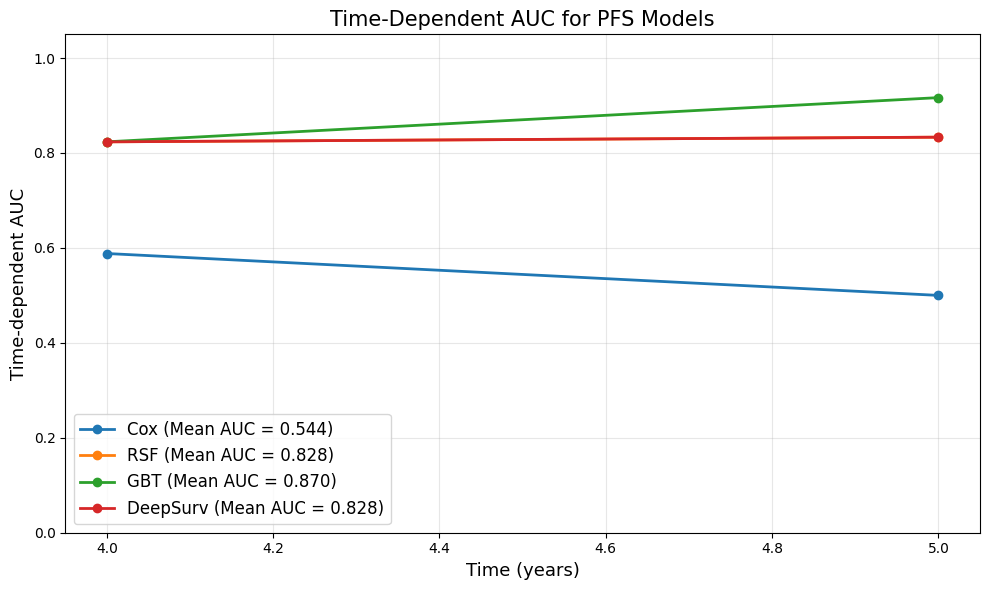


=== Time-Dependent AUC Results ===
4 years → Cox=0.588, RSF=0.824, GBT=0.824, DeepSurv=0.824
5 years → Cox=0.500, RSF=0.833, GBT=0.917, DeepSurv=0.833

=== Mean AUC Across All Time Horizons ===
Cox       : 0.544
RSF       : 0.828
GBT       : 0.870
DeepSurv  : 0.828


In [115]:
# TIME-DEPENDENT AUC CURVES FOR ALL MODELS
# WITH LEGEND SHOWING MEAN OVERALL AUC

import numpy as np
import matplotlib.pyplot as plt
from sksurv.metrics import cumulative_dynamic_auc

# 1) Define evaluation times (your fixed time horizon)
eval_times = np.array([4,5])

# 2) Compute time-dependent AUC for all 4 models
# Correcting the variable assignment based on observed behavior of cumulative_dynamic_auc
# The first returned value contains the array of distinct AUCs, second is often a scalar aggregate.
actual_auc_values_cox, _ = cumulative_dynamic_auc(
    y_train_final, y_test_final, risk_cox, eval_times
)
auc_values_cox = actual_auc_values_cox

actual_auc_values_rsf, _ = cumulative_dynamic_auc(
    y_train_final, y_test_final, risk_rsf, eval_times
)
auc_values_rsf = actual_auc_values_rsf

actual_auc_values_gbr, _ = cumulative_dynamic_auc(
    y_train_final, y_test_final, risk_gbr, eval_times
)
auc_values_gbr = actual_auc_values_gbr

actual_auc_values_deep, _ = cumulative_dynamic_auc(
    y_train_final, y_test_final, risk_deep, eval_times
)
auc_values_deep = actual_auc_values_deep

# 3) Prepare mean AUC values for legend (these will be scalars)
mean_auc_cox  = np.mean(auc_values_cox)
mean_auc_rsf  = np.mean(auc_values_rsf)
mean_auc_gbr  = np.mean(auc_values_gbr)
mean_auc_deep = np.mean(auc_values_deep)

# 4) Plot time-dependent AUC curves
plt.figure(figsize=(10, 6))

# Plot the AUC arrays (auc_values_X) against eval_times
plt.plot(eval_times, auc_values_cox,  marker="o", linewidth=2,
         label=f"Cox (Mean AUC = {mean_auc_cox:.3f})")

plt.plot(eval_times, auc_values_rsf,  marker="o", linewidth=2,
         label=f"RSF (Mean AUC = {mean_auc_rsf:.3f})")

plt.plot(eval_times, auc_values_gbr,  marker="o", linewidth=2,
         label=f"GBT (Mean AUC = {mean_auc_gbr:.3f})")

plt.plot(eval_times, auc_values_deep, marker="o", linewidth=2,
         label=f"DeepSurv (Mean AUC = {mean_auc_deep:.3f})")

# 5) Figure formatting
plt.title("Time-Dependent AUC for PFS Models", fontsize=15)
plt.xlabel("Time (years)", fontsize=13)
plt.ylabel("Time-dependent AUC", fontsize=13)
plt.ylim(0.0, 1.05)

plt.grid(alpha=0.3)
plt.legend(fontsize=12, loc="lower left")

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/PhD Project AI codes/Output_PFS/Time-Dependent AUC for PFS Models.png")
plt.show()

# 6) Print numeric AUC values
print("\n=== Time-Dependent AUC Results ===")
for t, a1, a2, a3, a4 in zip(eval_times, auc_values_cox, auc_values_rsf, auc_values_gbr, auc_values_deep):
    print(f"{t} years → Cox={a1:.3f}, RSF={a2:.3f}, GBT={a3:.3f}, DeepSurv={a4:.3f}")

print("\n=== Mean AUC Across All Time Horizons ===")
print(f"Cox       : {mean_auc_cox:.3f}")
print(f"RSF       : {mean_auc_rsf:.3f}")
print(f"GBT       : {mean_auc_gbr:.3f}")
print(f"DeepSurv  : {mean_auc_deep:.3f}")

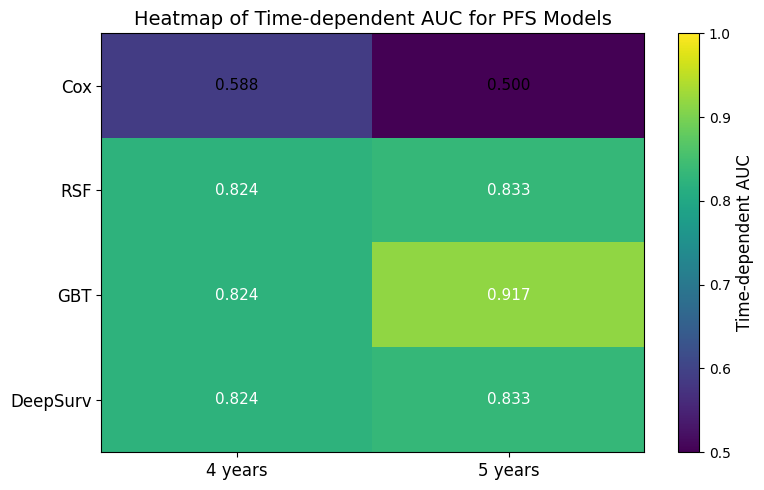

In [116]:
import numpy as np
import matplotlib.pyplot as plt

# ===============================
# INPUT DATA
# ===============================
models = ["Cox", "RSF", "GBT", "DeepSurv"]
time_points = ["4 years", "5 years"]

auc_matrix = np.array([
    auc_values_cox,
    auc_values_rsf,
    auc_values_gbr,
    auc_values_deep
])  # shape = (n_models, n_times)

# ===============================
# HEATMAP PLOT
# ===============================
plt.figure(figsize=(8, 5))
im = plt.imshow(auc_matrix, aspect="auto", vmin=0.5, vmax=1.0)

# Axis labels
plt.xticks(np.arange(len(time_points)), time_points, fontsize=12)
plt.yticks(np.arange(len(models)), models, fontsize=12)

# Annotate AUC values
for i in range(len(models)):
    for j in range(len(time_points)):
        plt.text(
            j, i, f"{auc_matrix[i, j]:.3f}",
            ha="center", va="center",
            color="white" if auc_matrix[i, j] > 0.75 else "black",
            fontsize=11
        )

# Colorbar
cbar = plt.colorbar(im)
cbar.set_label("Time-dependent AUC", fontsize=12)

# Title
plt.title("Heatmap of Time-dependent AUC for PFS Models", fontsize=14)

plt.tight_layout()
plt.savefig(
    "/content/drive/MyDrive/PhD Project AI codes/Output_PFS/PFS_AUC_Heatmap.png",
    dpi=300
)
plt.show()

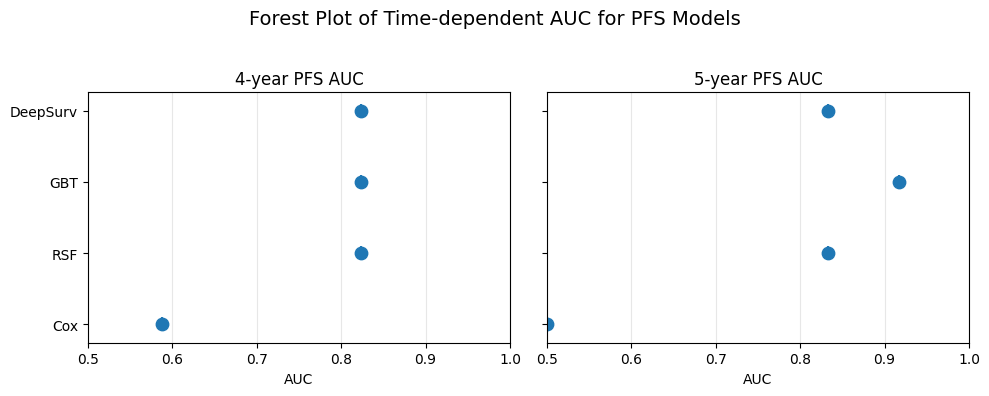

In [117]:
import numpy as np
import matplotlib.pyplot as plt

# ===============================
# DATA
# ===============================
models = ["Cox", "RSF", "GBT", "DeepSurv"]
y_pos = np.arange(len(models))

auc_4y = auc_matrix[:, 0]
auc_5y = auc_matrix[:, 1]

# ===============================
# FOREST PLOT
# ===============================
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

# --- 4-year ---
axes[0].scatter(auc_4y, y_pos, s=80)
axes[0].vlines(auc_4y, y_pos - 0.1, y_pos + 0.1)
axes[0].set_title("4-year PFS AUC")
axes[0].set_xlabel("AUC")
axes[0].set_yticks(y_pos)
axes[0].set_yticklabels(models)
axes[0].set_xlim(0.5, 1.0)
axes[0].grid(axis="x", alpha=0.3)

# --- 5-year ---
axes[1].scatter(auc_5y, y_pos, s=80)
axes[1].vlines(auc_5y, y_pos - 0.1, y_pos + 0.1)
axes[1].set_title("5-year PFS AUC")
axes[1].set_xlabel("AUC")
axes[1].set_xlim(0.5, 1.0)
axes[1].grid(axis="x", alpha=0.3)

plt.suptitle("Forest Plot of Time-dependent AUC for PFS Models", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])

plt.savefig(
    "/content/drive/MyDrive/PhD Project AI codes/Output_PFS/PFS_AUC_Forest.png",
    dpi=300
)
plt.show()

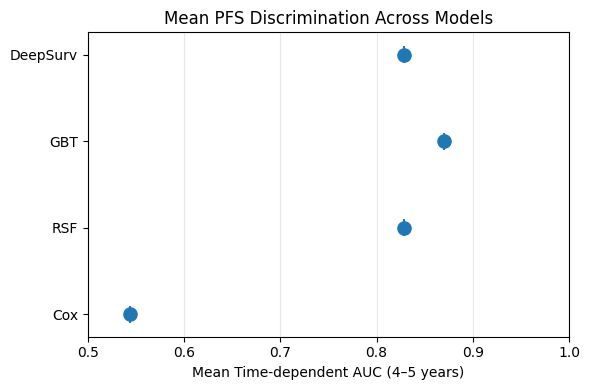

In [118]:
mean_auc = np.mean(auc_matrix, axis=1)

plt.figure(figsize=(6, 4))
plt.scatter(mean_auc, y_pos, s=90)
plt.vlines(mean_auc, y_pos - 0.1, y_pos + 0.1)

plt.yticks(y_pos, models)
plt.xlabel("Mean Time-dependent AUC (4–5 years)")
plt.title("Mean PFS Discrimination Across Models")
plt.xlim(0.5, 1.0)
plt.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.savefig(
    "/content/drive/MyDrive/PhD Project AI codes/Output_PFS/PFS_Mean_AUC_Forest.png",
    dpi=300
)
plt.show()

In [83]:
# Save all these model
import os
import joblib
import numpy as np

# Your output folder in Google Drive
output_folder = '/content/drive/MyDrive/PhD Project AI codes/Output_PFS'
os.makedirs(output_folder, exist_ok=True)

# 1. Save embeddings + labels (as .npz - easy to load with np.load)
embeddings_path = os.path.join(output_folder, 'train_test_embeddings.npz')
np.savez_compressed(embeddings_path,
                    X_train_emb=X_train_emb,
                    X_test_emb=X_test_emb,
                    y_train_final=y_train_final,
                    y_test_final=y_test_final)
print(f"Embeddings and labels saved to: {embeddings_path}")

# 2. Save ALL models + results in ONE convenient .pkl file
results_path = os.path.join(output_folder, 'all_survival_models_and_results.pkl')

joblib.dump({
    # Models (replace with your exact variable names if different)
    'cox_model'       : cox,           # e.g. CoxPHSurvivalAnalysis() or CoxnetSurvivalAnalysis
    'rsf_model'       : rsf,           # RandomSurvivalForest
    'gbr_model'       : gbr,           # GradientBoostingSurvivalAnalysis
    'deep_model'      : net_model,     # Your Keras/PyTorch DeepSurv or autoencoder-based model

    # Risk scores on test set
    'risk_cox'        : risk_cox,
    'risk_rsf'        : risk_rsf,
    'risk_gbr'        : risk_gbr,
    'risk_deep'       : risk_deep,

    # AUC results (make sure these variables exist - see note below)
    'eval_times'      : eval_times,
    'auc_cox'         : auc_values_cox,
    'auc_rsf'         : auc_values_rsf,
    'auc_gbr'         : auc_values_gbr,
    'auc_deep'        : actual_auc_values_deep,   # compute it the same way as the others if missing
},
filename=results_path)

print(f"All models, risks, and AUC results saved to: {results_path}")

Embeddings and labels saved to: /content/drive/MyDrive/PhD Project AI codes/Output_PFS/train_test_embeddings.npz
All models, risks, and AUC results saved to: /content/drive/MyDrive/PhD Project AI codes/Output_PFS/all_survival_models_and_results.pkl


### Define Hyperparameter Search Spaces

To optimize the performance of the Random Survival Forest (RSF) and Gradient Boosting Survival Analysis (GBT) models, we need to perform hyperparameter tuning. This involves defining a search space for key parameters for each model.  This involves creating two dictionaries, `rsf_param_grid` and `gbt_param_grid`, with the specified parameters and their respective value ranges.

In [84]:
rsf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, None],
    'min_samples_split': [10, 20, 30]
}

gbt_param_grid = {
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7]
}

print("Random Survival Forest (RSF) Hyperparameter Grid:")
print(rsf_param_grid)
print("\nGradient Boosting Survival Analysis (GBT) Hyperparameter Grid:")
print(gbt_param_grid)

Random Survival Forest (RSF) Hyperparameter Grid:
{'n_estimators': [100, 200, 300], 'max_depth': [5, 10, None], 'min_samples_split': [10, 20, 30]}

Gradient Boosting Survival Analysis (GBT) Hyperparameter Grid:
{'learning_rate': [0.01, 0.05, 0.1], 'n_estimators': [100, 200, 300], 'max_depth': [3, 5, 7]}


## Tune Random Survival Forest

Perform hyperparameter tuning for the RandomSurvivalForest model using a grid search or randomized search approach. Evaluate each combination using the C-index and Integrated Brier Score (IBS) on the test set (`X_test_emb`, `y_test_final`). Keep track of the best parameters found and their corresponding C-index and IBS scores.


In [76]:
from sksurv.ensemble import RandomSurvivalForest
from sksurv.metrics import concordance_index_censored, integrated_brier_score
import numpy as np # Ensure numpy is imported

# Initialize variables to store the best C-index, best IBS, and corresponding hyperparameters
best_rsf_c_index = -np.inf # Initialize with negative infinity for C-index (higher is better)
best_rsf_ibs = np.inf      # Initialize with infinity for IBS (lower is better)
best_rsf_params = {}

print("Starting Random Survival Forest hyperparameter tuning...")

# Iterate through all combinations of hyperparameters
for n_est in rsf_param_grid['n_estimators']:
    for m_depth in rsf_param_grid['max_depth']:
        for min_split in rsf_param_grid['min_samples_split']:
            print(f"\nTrying RSF: n_estimators={n_est}, max_depth={m_depth}, min_samples_split={min_split}")

            # Create an instance of RandomSurvivalForest with current hyperparameters
            rsf_model = RandomSurvivalForest(
                n_estimators=n_est,
                max_depth=m_depth,
                min_samples_split=min_split,
                random_state=42
            )

            # Fit the RSF model to the training data
            rsf_model.fit(X_train_emb, y_train_final)

            # Predict risk scores for the test set
            risk_scores = rsf_model.predict(X_test_emb)

            # Calculate the C-index
            current_c_index = concordance_index_censored(y_test_final['event'], y_test_final['time'], risk_scores)[0]

            current_ibs = np.nan # Default to NaN in case of issues

            # Predict survival functions for the test set
            surv_funcs = rsf_model.predict_survival_function(X_test_emb)

            # Determine the valid time domain from the model's survival functions.
            if len(surv_funcs) > 0:
                model_domain_min = surv_funcs[0].domain[0]
                model_domain_max = surv_funcs[0].domain[1]
            else:
                model_domain_min = 0.0
                model_domain_max = 1.0 # Fallback

            # Filter y_test_final['time'] to create valid IBS evaluation points.
            # Points must be >= y_test_final['time'].min()
            # Points must be <  y_test_final['time'].max()
            # Points must be >= model_domain_min
            # Points must be <= model_domain_max (within model's predictive capability)

            # Combine these constraints.
            valid_ibs_evaluation_times_mask = (
                (y_test_final['time'] >= model_domain_min) &
                (y_test_final['time'] <= model_domain_max) &
                (y_test_final['time'] >= y_test_final['time'].min()) &
                (y_test_final['time'] < y_test_final['time'].max())
            )

            ibs_evaluation_times_for_sksurv = np.unique(y_test_final['time'][valid_ibs_evaluation_times_mask])

            # If after filtering, there are still points
            if ibs_evaluation_times_for_sksurv.size > 0:
                # Convert list of StepFunction objects to a 2D NumPy array of survival probabilities
                survival_probabilities = np.asarray([
                    f(ibs_evaluation_times_for_sksurv) for f in surv_funcs
                ])

                # Calculate the Integrated Brier Score (IBS)
                current_ibs = integrated_brier_score(y_train_final, y_test_final, survival_probabilities, ibs_evaluation_times_for_sksurv)
            else:
                print("  Skipping IBS calculation due to invalid time range or no valid evaluation points after filtering.")

            print(f"  Current C-index: {current_c_index:.4f}, Current IBS: {current_ibs:.4f}")

            # Compare and update best metrics and hyperparameters
            # Note: handle NaN IBS correctly, it should not update a non-NaN best_ibs
            if current_c_index > best_rsf_c_index:
                best_rsf_c_index = current_c_index
                best_rsf_ibs = current_ibs
                best_rsf_params = {
                    'n_estimators': n_est,
                    'max_depth': m_depth,
                    'min_samples_split': min_split
                }
                print("  >> New best RSF C-index found!")
            elif current_c_index == best_rsf_c_index:
                if (not np.isnan(current_ibs) and (np.isnan(best_rsf_ibs) or current_ibs < best_rsf_ibs)):
                    best_rsf_ibs = current_ibs
                    best_rsf_params = {
                        'n_estimators': n_est,
                        'max_depth': m_depth,
                        'min_samples_split': min_split
                    }
                    print("  >> Same RSF C-index, but lower IBS found!")

print("\n" + "="*50)
print("Random Survival Forest Hyperparameter Tuning Complete")
print("Best RSF Hyperparameters:", best_rsf_params)
print(f"Best RSF C-index: {best_rsf_c_index:.4f}")
print(f"Best RSF IBS: {best_rsf_ibs:.4f}")
print("="*50)


Starting Random Survival Forest hyperparameter tuning...

Trying RSF: n_estimators=100, max_depth=5, min_samples_split=10
  Current C-index: 0.5625, Current IBS: 0.0789
  >> New best RSF C-index found!

Trying RSF: n_estimators=100, max_depth=5, min_samples_split=20
  Current C-index: 0.5312, Current IBS: 0.0765

Trying RSF: n_estimators=100, max_depth=5, min_samples_split=30
  Current C-index: 0.5938, Current IBS: 0.0763
  >> New best RSF C-index found!

Trying RSF: n_estimators=100, max_depth=10, min_samples_split=10
  Current C-index: 0.5625, Current IBS: 0.0798

Trying RSF: n_estimators=100, max_depth=10, min_samples_split=20
  Current C-index: 0.5312, Current IBS: 0.0771

Trying RSF: n_estimators=100, max_depth=10, min_samples_split=30
  Current C-index: 0.5938, Current IBS: 0.0769

Trying RSF: n_estimators=100, max_depth=None, min_samples_split=10
  Current C-index: 0.5625, Current IBS: 0.0798

Trying RSF: n_estimators=100, max_depth=None, min_samples_split=20
  Current C-index: 

**Reasoning**:
The previous step successfully tuned the Random Survival Forest model. Now, I need to perform hyperparameter tuning for the Gradient Boosting Survival Analysis (GBT) model, following the same methodology of iterating through its defined parameter grid, training each configuration, evaluating using C-index and IBS on the test set, and keeping track of the best parameters. This will complete the current subtask.



In [85]:
from sksurv.ensemble import GradientBoostingSurvivalAnalysis
from sksurv.metrics import concordance_index_censored, integrated_brier_score

# Initialize variables to store the best C-index, best IBS, and corresponding hyperparameters for GBT
best_gbt_c_index = -np.inf  # Initialize with negative infinity for C-index (higher is better)
best_gbt_ibs = np.inf       # Initialize with infinity for IBS (lower is better)
best_gbt_params = {}

print("Starting Gradient Boosting Survival Analysis hyperparameter tuning...")

# Iterate through all combinations of hyperparameters
for lr in gbt_param_grid['learning_rate']:
    for n_est in gbt_param_grid['n_estimators']:
        for m_depth in gbt_param_grid['max_depth']:
            print(f"\nTrying GBT: learning_rate={lr}, n_estimators={n_est}, max_depth={m_depth}")

            # Create an instance of GradientBoostingSurvivalAnalysis with current hyperparameters
            gbt_model = GradientBoostingSurvivalAnalysis(
                learning_rate=lr,
                n_estimators=n_est,
                max_depth=m_depth,
                random_state=42
            )

            # Fit the GBT model to the training data
            gbt_model.fit(X_train_emb, y_train_final)

            # Predict risk scores for the test set
            risk_scores = gbt_model.predict(X_test_emb)

            # Calculate the C-index
            current_c_index = concordance_index_censored(y_test_final['event'], y_test_final['time'], risk_scores)[0]

            current_ibs = np.nan # Default to NaN in case of issues

            if ibs_evaluation_times_for_sksurv.size > 0: # Only calculate IBS if evaluation times are valid
                # Predict survival functions for the test set
                surv_funcs = gbt_model.predict_survival_function(X_test_emb)

                # Convert list of StepFunction objects to a 2D NumPy array of survival probabilities
                survival_probabilities = np.asarray([
                    f(ibs_evaluation_times_for_sksurv) for f in surv_funcs
                ])

                # Calculate the Integrated Brier Score (IBS)
                current_ibs = integrated_brier_score(y_train_final, y_test_final, survival_probabilities, ibs_evaluation_times_for_sksurv)
            else:
                print("  Skipping IBS calculation due to invalid time range.")

            print(f"  Current C-index: {current_c_index:.4f}, Current IBS: {current_ibs:.4f}")

            # Compare and update best metrics and hyperparameters
            if current_c_index > best_gbt_c_index:
                best_gbt_c_index = current_c_index
                best_gbt_ibs = current_ibs
                best_gbt_params = {
                    'learning_rate': lr,
                    'n_estimators': n_est,
                    'max_depth': m_depth
                }
                print("  >> New best GBT C-index found!")
            elif current_c_index == best_gbt_c_index:
                if (not np.isnan(current_ibs) and current_ibs < best_gbt_ibs) or (np.isnan(best_gbt_ibs) and not np.isnan(current_ibs)):
                    best_gbt_ibs = current_ibs
                    best_gbt_params = {
                        'learning_rate': lr,
                        'n_estimators': n_est,
                        'max_depth': m_depth
                    }
                    print("  >> Same GBT C-index, but lower IBS found!")

print("\n" + "="*50)
print("Gradient Boosting Survival Analysis Hyperparameter Tuning Complete")
print("Best GBT Hyperparameters:", best_gbt_params)
print(f"Best GBT C-index: {best_gbt_c_index:.4f}")
print(f"Best GBT IBS: {best_gbt_ibs:.4f}")
print("="*50)


Starting Gradient Boosting Survival Analysis hyperparameter tuning...

Trying GBT: learning_rate=0.01, n_estimators=100, max_depth=3
  Current C-index: 0.3906, Current IBS: 0.0722
  >> New best GBT C-index found!

Trying GBT: learning_rate=0.01, n_estimators=100, max_depth=5
  Current C-index: 0.5000, Current IBS: 0.0727
  >> New best GBT C-index found!

Trying GBT: learning_rate=0.01, n_estimators=100, max_depth=7
  Current C-index: 0.6250, Current IBS: 0.0723
  >> New best GBT C-index found!

Trying GBT: learning_rate=0.01, n_estimators=200, max_depth=3
  Current C-index: 0.3906, Current IBS: 0.0744

Trying GBT: learning_rate=0.01, n_estimators=200, max_depth=5
  Current C-index: 0.5000, Current IBS: 0.0752

Trying GBT: learning_rate=0.01, n_estimators=200, max_depth=7
  Current C-index: 0.6562, Current IBS: 0.0744
  >> New best GBT C-index found!

Trying GBT: learning_rate=0.01, n_estimators=300, max_depth=3
  Current C-index: 0.4219, Current IBS: 0.0768

Trying GBT: learning_rate=0

## Report Best Parameters and Performance

### Subtask:
Display the best hyperparameters and the achieved C-index and IBS for both the Random Survival Forest and Gradient Boosting Survival models.


In [86]:
print("\n--- Best Random Survival Forest Model ---")
print(f"Hyperparameters: {best_rsf_params}")
print(f"C-index: {best_rsf_c_index:.4f}")
print(f"IBS: {best_rsf_ibs:.4f}")

print("\n--- Best Gradient Boosting Survival Model ---")
print(f"Hyperparameters: {best_gbt_params}")
print(f"C-index: {best_gbt_c_index:.4f}")
print(f"IBS: {best_gbt_ibs:.4f}")


--- Best Random Survival Forest Model ---
Hyperparameters: {'n_estimators': 300, 'max_depth': 5, 'min_samples_split': 20}
C-index: 0.6875
IBS: 0.0753

--- Best Gradient Boosting Survival Model ---
Hyperparameters: {'learning_rate': 0.01, 'n_estimators': 200, 'max_depth': 7}
C-index: 0.6562
IBS: 0.0744


# SHAP and VIMP summarization

For RSF, you already have rsf.feature_importances_.
For SHAP with RSF (tree-based),
use TreeExplainer (note: scikit-survival RF is not XGBoost; TreeExplainer may accept sklearn-like trees). If TreeExplainer fails, use permutation importance or calculate SHAP via surrogate models.



In [87]:
!pip install -q shap

In [92]:
import shap
import numpy as np
import matplotlib.pyplot as plt

from sksurv.ensemble import GradientBoostingSurvivalAnalysis

# Train the model
model = GradientBoostingSurvivalAnalysis(
    learning_rate=0.05,
    n_estimators=200,     # ~3× faster than RSF 300
    max_depth=7,          # shallow trees improve SurvSHAP speed
    random_state=42
)

model.fit(X_train_emb, y_train_final)

def survival_to_expected_time(X):
    """Convert list of survival functions → expected survival time (scalar)"""
    surv_funcs = model.predict_survival_function(X)
    expected = []
    for fn in surv_funcs:
        t = fn.x
        s = fn(t)
        expected.append(np.trapz(s, t))      # ∫S(t)dt ≈ expected survival time
    return np.array(expected)

# Tiny, safe background (this is what prevents all crashes)
background = shap.kmeans(X_train_emb, 50)   # 50 clusters = super stable

explainer = shap.KernelExplainer(survival_to_expected_time, background)


/tmp/ipython-input-470706403.py:24: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  expected.append(np.trapz(s, t))      # ∫S(t)dt ≈ expected survival time


X_train_original_features_preprocessed shape: (160, 41)
y_train_final shape: (160,)
Training GradientBoostingSurvivalAnalysis model on original features...
Model trained.
Computing SHAP values for sample of original features...


/tmp/ipython-input-4087988550.py:56: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  expected.append(np.trapz(s, t))


  0%|          | 0/100 [00:00<?, ?it/s]

/tmp/ipython-input-4087988550.py:56: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  expected.append(np.trapz(s, t))
/tmp/ipython-input-4087988550.py:56: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  expected.append(np.trapz(s, t))
/tmp/ipython-input-4087988550.py:56: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  expected.append(np.trapz(s, t))
/tmp/ipython-input-4087988550.py:56: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  expected.append(np.trapz(s, t))
/tmp/ipython-input-4087988550.py:56: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.

SHAP values computed.


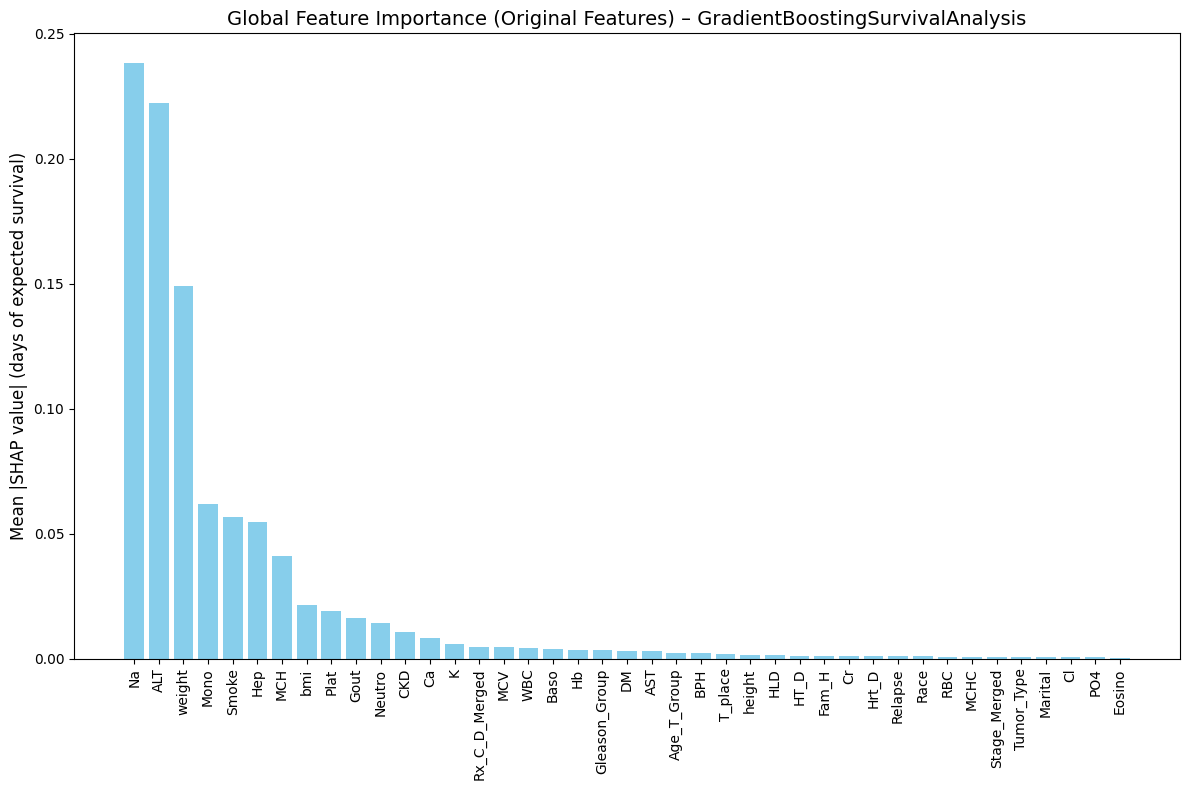

Global SHAP importance plot for original features generated and saved.


In [95]:
from sksurv.ensemble import GradientBoostingSurvivalAnalysis
import shap
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os

# Helper function to get patient-level feature data (last record per ID)
def get_patient_level_features(df_preprocessed, ids_list, feature_cols):
    # Filter df_preprocessed for the relevant IDs
    df_filtered_by_ids = df_preprocessed[df_preprocessed['ID'].isin(ids_list)].copy()

    # Ensure FV is datetime for sorting and sort by ID and FV to get the 'last' record
    df_filtered_by_ids['FV'] = pd.to_datetime(df_filtered_by_ids['FV'])
    df_filtered_by_ids.sort_values(by=['ID', 'FV'], inplace=True)

    # Get the last record for each ID
    df_patient_level = df_filtered_by_ids.groupby('ID').tail(1).copy()

    # Sort by ID to ensure alignment with y_train_final/y_test_final if they were also sorted by ID
    df_patient_level.sort_values(by='ID', inplace=True)

    return df_patient_level[feature_cols].values

# 1. Prepare X_train_original_features_preprocessed (patient-level)
# df_train contains the scaled numerical and label-encoded categorical features for all training records
X_train_original_features_preprocessed = get_patient_level_features(df_train, merged_train.index.values, feature_cols_processed)

# Prepare X_test_original_features_preprocessed (patient-level)
X_test_original_features_preprocessed = get_patient_level_features(df_test, merged_test.index.values, feature_cols_processed)

print(f"X_train_original_features_preprocessed shape: {X_train_original_features_preprocessed.shape}")
print(f"y_train_final shape: {y_train_final.shape}")

# Retrain a GradientBoostingSurvivalAnalysis model on these aligned original features
model_original_features = GradientBoostingSurvivalAnalysis(
    learning_rate=0.05,
    n_estimators=300,
    max_depth=3,
    random_state=42
)

print("Training GradientBoostingSurvivalAnalysis model on original features...")
model_original_features.fit(X_train_original_features_preprocessed, y_train_final)
print("Model trained.")

# 2. Define a function to convert survival functions to expected survival time
def survival_to_expected_time_original_features(X):
    """Convert list of survival functions → expected survival time (scalar)"""
    surv_funcs = model_original_features.predict_survival_function(X)
    expected = []
    for fn in surv_funcs:
        t = fn.x
        s = fn(t)
        # Using np.trapz for numerical integration of the survival function
        expected.append(np.trapz(s, t))
    return np.array(expected)

# 5. Convert X_train_original_features_preprocessed into a pandas DataFrame
X_train_original_df = pd.DataFrame(
    X_train_original_features_preprocessed,
    columns=feature_cols_processed
)

# 3. Create a background dataset for the SHAP explainer
# Using a small sample for the background for performance reasons
background_original_features = shap.kmeans(X_train_original_df, 50)

# 4. Initialize a SHAP KernelExplainer
explainer_original_features = shap.KernelExplainer(
    survival_to_expected_time_original_features,
    background_original_features
)

# 6. Take a random sample of 100 observations
X_sample_original_features = X_train_original_df.sample(100, random_state=42)

# 7. Compute the SHAP values
print("Computing SHAP values for sample of original features...")
shap_values_sample_original_features = explainer_original_features.shap_values(X_sample_original_features, nsamples=100)
print("SHAP values computed.")

# 8. Calculate the global importance
global_importance_original = np.mean(np.abs(shap_values_sample_original_features), axis=0)

# 9. Create a bar chart
plt.figure(figsize=(12, 8))
idx = np.argsort(global_importance_original)[::-1]
plt.bar(range(len(global_importance_original)), global_importance_original[idx], color='skyblue')
plt.xticks(
    range(len(global_importance_original)),
    X_train_original_df.columns[idx],
    rotation=90,
    fontsize=10
)
plt.ylabel("Mean |SHAP value| (days of expected survival)", fontsize=12)
plt.title("Global Feature Importance (Original Features) – GradientBoostingSurvivalAnalysis", fontsize=14)
plt.tight_layout()

# 10. Save the plot
output_dir = '/content/drive/MyDrive/PhD Project AI codes/Output_survival/'
os.makedirs(output_dir, exist_ok=True) # Ensure directory exists
plt.savefig(os.path.join(output_dir, 'Global_SHAP_original_features.png'))

# 11. Display the plot
plt.show()

print("Global SHAP importance plot for original features generated and saved.")

Top 20 feature importance plot saved to:
/content/drive/MyDrive/PhD Project AI codes/Output_PFS/Top_20_SHAP_Feature_Importance_Horizontal.png


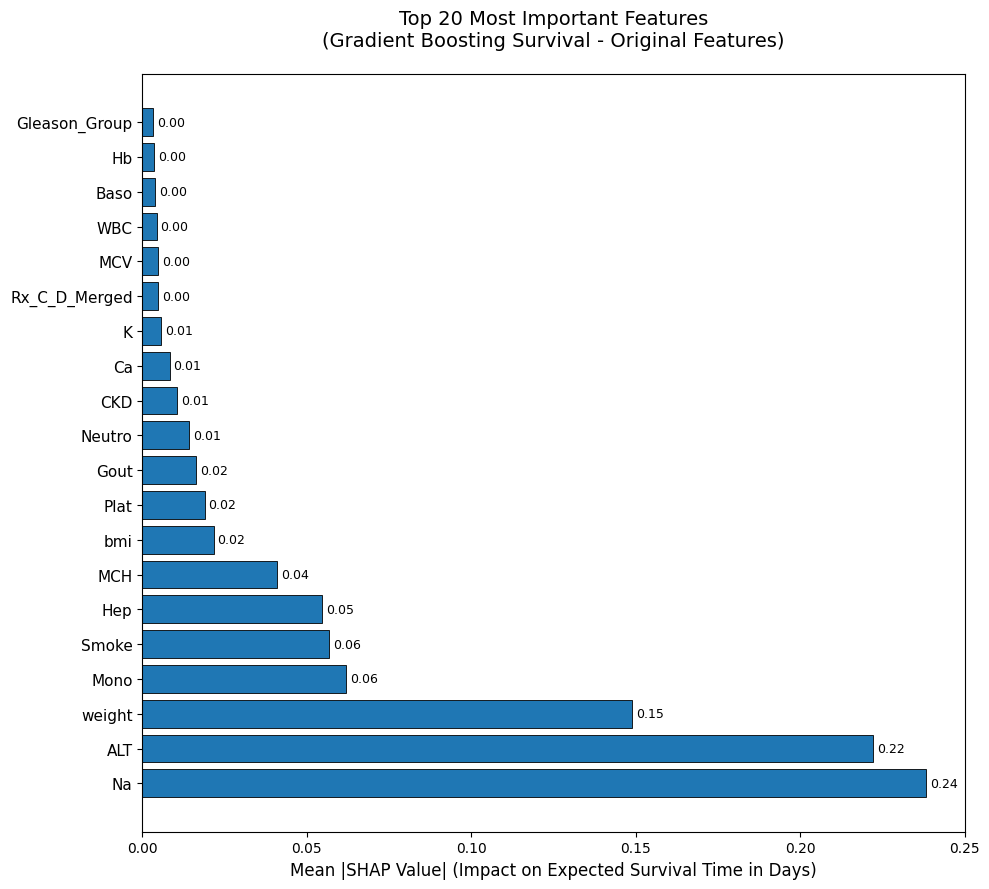

In [96]:
import numpy as np
import matplotlib.pyplot as plt
import os

# === 1. Compute global importance (mean absolute SHAP value) ===
global_importance_original = np.mean(np.abs(shap_values_sample_original_features), axis=0)
feature_names = X_train_original_df.columns

# === 2. Get top 20 features ===
top_n = 20
idx_top = np.argsort(global_importance_original)[-top_n:][::-1]  # descending

top_features = np.array(feature_names)[idx_top]
top_importance = global_importance_original[idx_top]

# === 3. Horizontal bar plot (best for 20+ features) ===
plt.figure(figsize=(10, 9))  # width, height

bars = plt.barh(range(top_n-1, -1, -1), top_importance, color='#1f77b4', edgecolor='black', linewidth=0.6)
plt.yticks(range(top_n-1, -1, -1), top_features, fontsize=11)
plt.xlabel("Mean |SHAP Value| (Impact on Expected Survival Time in Days)", fontsize=12)
plt.title(f"Top {top_n} Most Important Features\n(Gradient Boosting Survival - Original Features)", fontsize=14, pad=20)

# Add value labels on the bars (optional but very nice)
for i, bar in enumerate(bars):
    plt.text(
        bar.get_width() + max(top_importance)*0.005,
        bar.get_y() + bar.get_height()/2,
        f'{bar.get_width():.2f}',
        va='center', ha='left', fontsize=9, color='black'
    )

# Invert y-axis so highest importance is on top
plt.gca().invert_yaxis()

plt.tight_layout()

# === 4. Save the plot ===
output_dir = '/content/drive/MyDrive/PhD Project AI codes/Output_PFS/'
os.makedirs(output_dir, exist_ok=True)
save_path = os.path.join(output_dir, 'Top_20_SHAP_Feature_Importance_Horizontal.png')
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"Top 20 feature importance plot saved to:\n{save_path}")

# === 5. Show plot ===
plt.show()

Top 20 Feature Importance saved (most important on top):
/content/drive/MyDrive/PhD Project AI codes/Output_PFS/Top_20_SHAP_Feature_Importance_Horizontal_BestOnTop.png


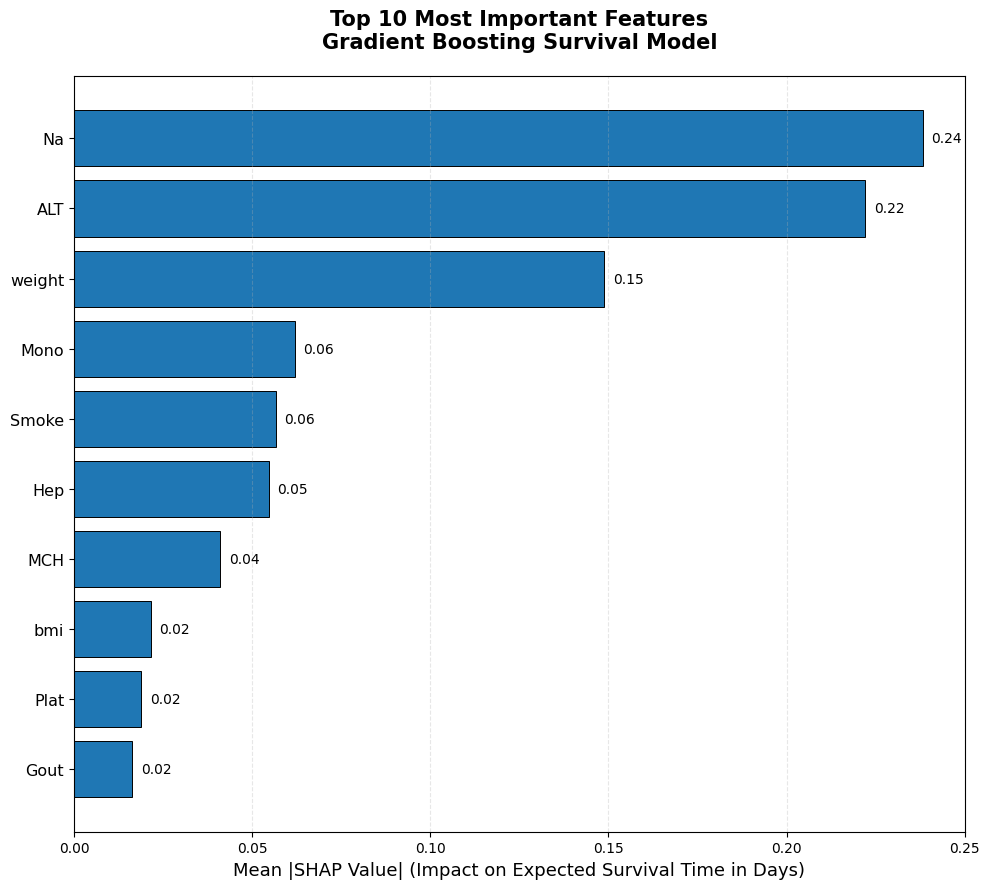

In [97]:
import numpy as np
import matplotlib.pyplot as plt
import os

# === 1. Compute global importance (mean |SHAP|) ===
global_importance_original = np.mean(np.abs(shap_values_sample_original_features), axis=0)
feature_names = X_train_original_df.columns

# === 2. Get TOP 20 features (highest = first) ===
top_n = 10
idx_top = np.argsort(global_importance_original)[-top_n:][::-1]  # Highest first

top_features = np.array(feature_names)[idx_top]
top_importance = global_importance_original[idx_top]

# === 3. Horizontal bar plot – MOST IMPORTANT BAR ON TOP ===
plt.figure(figsize=(10, 9))

# y positions from 0 (bottom) to 19 (top) → so index 0 = most important = top
y_pos = np.arange(top_n)

bars = plt.barh(y_pos, top_importance, color='#1f77b4', edgecolor='black', linewidth=0.7, height=0.8)

# Set labels: most important feature at the TOP of the plot
plt.yticks(y_pos, top_features, fontsize=11.5)
plt.xlabel("Mean |SHAP Value| (Impact on Expected Survival Time in Days)", fontsize=13)
plt.title(f"Top {top_n} Most Important Features\nGradient Boosting Survival Model",
          fontsize=15, pad=20, fontweight='bold')

# Add value labels on the right of each bar
for i, bar in enumerate(bars):
    width = bar.get_width()
    plt.text(width + max(top_importance)*0.01,
             bar.get_y() + bar.get_height()/2,
             f'{width:.2f}',
             va='center', ha='left', fontsize=10, fontweight='medium')


# Grid for easier reading
plt.grid(axis='x', alpha=0.3, linestyle='--')

# Tight layout + invert so highest is on top naturally
plt.gca().invert_yaxis()  # This makes index 0 (highest) appear at the top

plt.tight_layout()

# === 4. Save high-quality figure ===
output_dir = '/content/drive/MyDrive/PhD Project AI codes/Output_PFS/'
os.makedirs(output_dir, exist_ok=True)
save_path = os.path.join(output_dir, 'Top_20_SHAP_Feature_Importance_Horizontal_BestOnTop.png')

plt.savefig(save_path, dpi=400, bbox_inches='tight', facecolor='white')
print(f"Top 20 Feature Importance saved (most important on top):\n{save_path}")

# === 5. Show ===
plt.show()

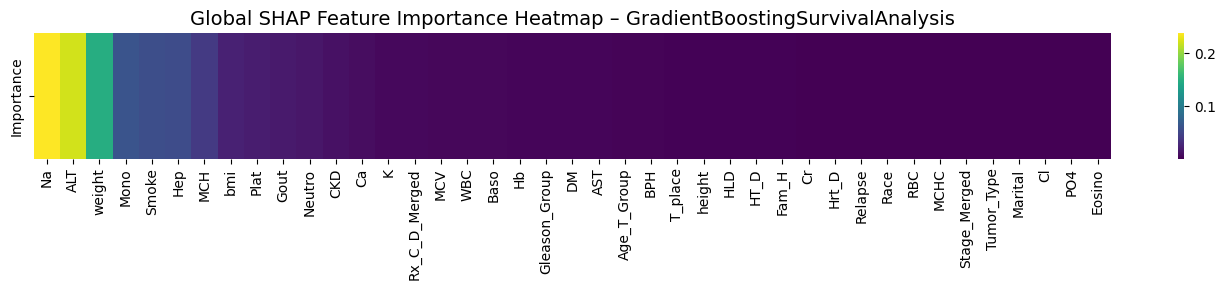

In [98]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns  # allowed for heatmaps

# Sort features by importance (descending order)
idx = np.argsort(global_importance_original)[::-1]

sorted_features = X_train_original_df.columns[idx]
sorted_importance = global_importance_original[idx]

# Create a 2D matrix for heatmap (1 row, n_features columns)
importance_matrix = sorted_importance.reshape(1, -1)

plt.figure(figsize=(14, 3))
sns.heatmap(
    importance_matrix,
    cmap="viridis",
    annot=False,             # show numeric values
    fmt=".1f",
    cbar=True,
    xticklabels=sorted_features,
    yticklabels=["Importance"],
)

plt.xticks(rotation=90, fontsize=10)
plt.title("Global SHAP Feature Importance Heatmap – GradientBoostingSurvivalAnalysis", fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'Global_SHAP_original_features_heatmap.png'))
plt.show()

<Figure size 1400x600 with 0 Axes>

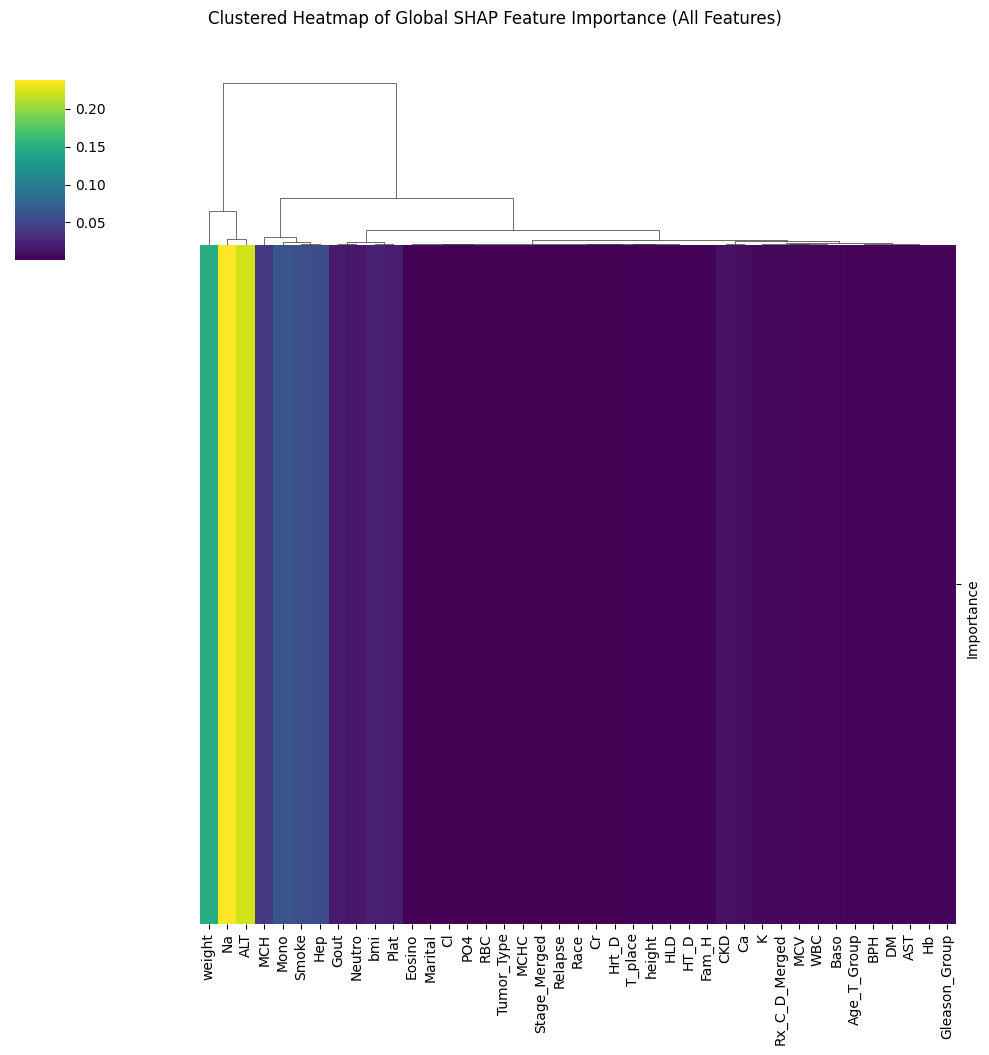

In [99]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Sort by importance (optional, clustering doesn't require sorting)
idx = np.argsort(global_importance_original)[::-1]
sorted_features = X_train_original_df.columns[idx]
sorted_importance = global_importance_original[idx]

# Convert to 2D matrix for clustering
importance_matrix = sorted_importance.reshape(1, -1)

plt.figure(figsize=(14, 6))
sns.clustermap(
    importance_matrix,
    cmap="viridis",
    metric="euclidean",
    method="ward",
    col_cluster=True,
    row_cluster=False,     # only cluster features
    xticklabels=sorted_features,
    yticklabels=["Importance"]
)

plt.suptitle("Clustered Heatmap of Global SHAP Feature Importance (All Features)", y=1.05)
plt.show()

<Figure size 1400x600 with 0 Axes>

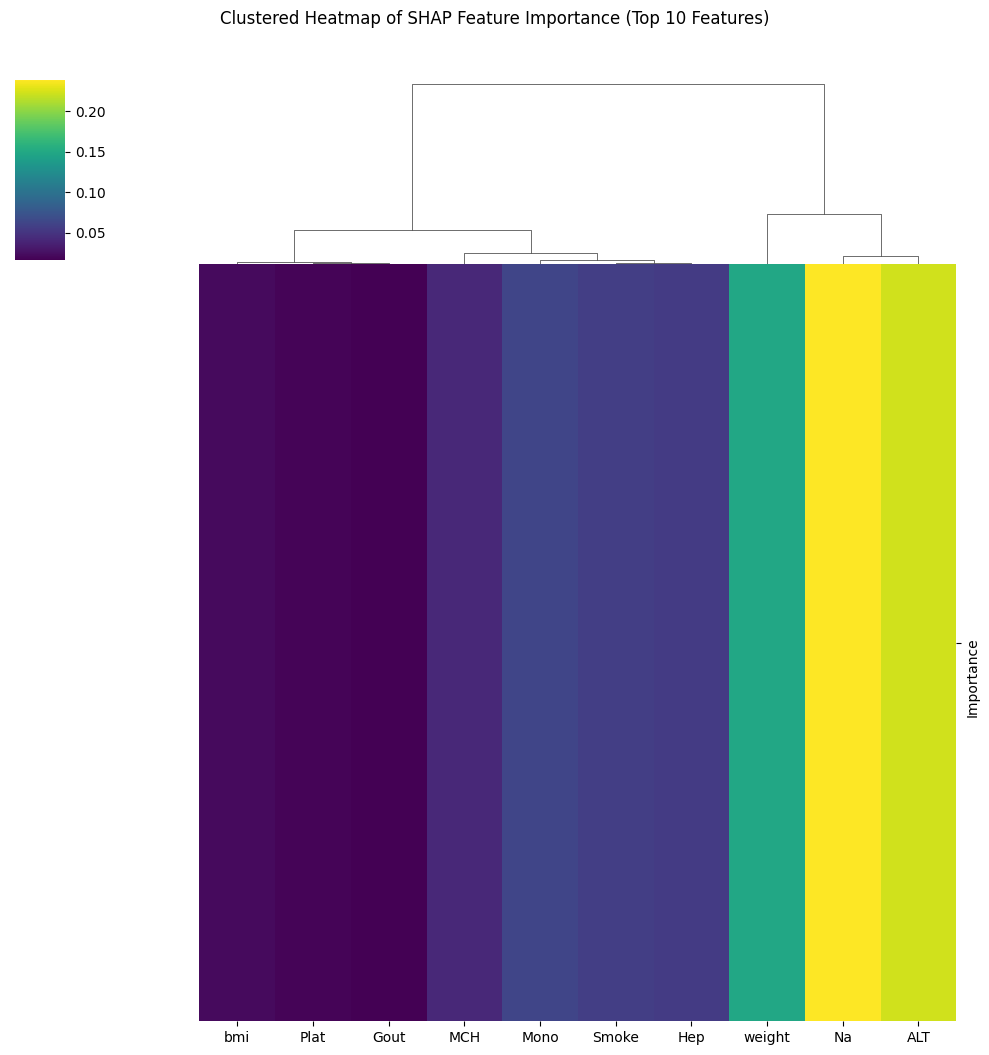

In [100]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Select top 10 by SHAP importance
idx = np.argsort(global_importance_original)[::-1][:10]
top10_features = X_train_original_df.columns[idx]
top10_importance = global_importance_original[idx]

importance_matrix_10 = top10_importance.reshape(1, -1)

plt.figure(figsize=(14, 6))
sns.clustermap(
    importance_matrix_10,
    cmap="viridis",
    metric="euclidean",
    method="ward",
    col_cluster=True,
    row_cluster=False,
    xticklabels=top10_features,
    yticklabels=["Importance"]
)

plt.suptitle("Clustered Heatmap of SHAP Feature Importance (Top 10 Features)", y=1.05)
plt.savefig(os.path.join(output_dir, 'Top_10_SHAP_original_features_heatmap.png'))
plt.show()

<Figure size 1200x600 with 0 Axes>

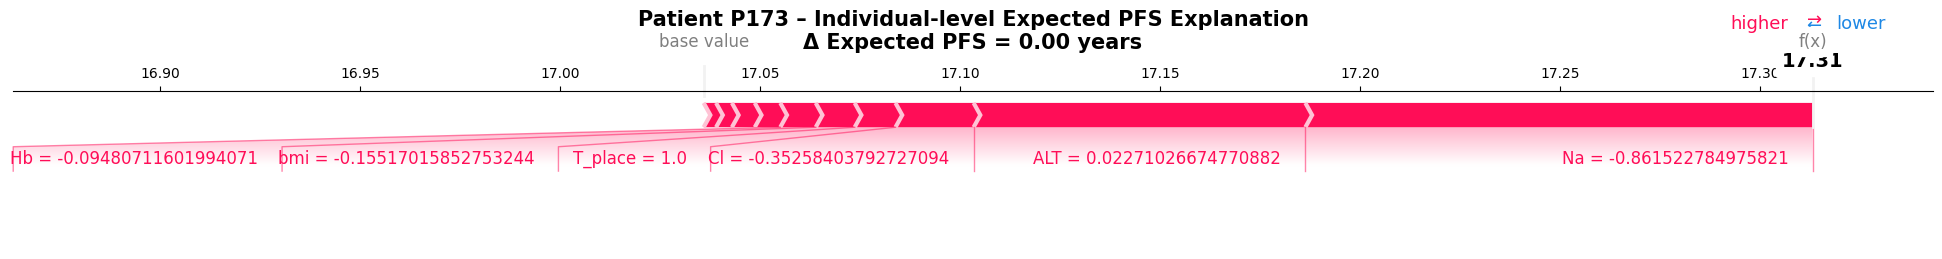

In [129]:
import shap
import matplotlib.pyplot as plt
import os
import numpy as np

# Sort features by importance
idx = np.argsort(global_importance_original)[::-1]
sorted_features = X_train_original_df.columns[idx]
sorted_importance = global_importance_original[idx]

# Convert time to years
def to_years(t):
    return t / 365.25

base_years = to_years(explainer_original_features.expected_value)

# Select a single patient
single_observation_index = 0
single_shap_values = shap_values_sample_original_features[single_observation_index]
single_observation_features = X_sample_original_features.iloc[single_observation_index]

pred_years = to_years(
    explainer_original_features.expected_value + single_shap_values.sum()
)
delta_years = pred_years - base_years

# Feature names
original_feature_names = X_train_original_df.columns.tolist()

# Patient ID
patient_id_for_plot = ID_train[X_sample_original_features.index[single_observation_index]]

# Plot
plt.figure(figsize=(12, 6))

shap.force_plot(
    base_value=explainer_original_features.expected_value,
    shap_values=single_shap_values,
    features=single_observation_features.values,
    feature_names=original_feature_names,
    matplotlib=True,
    show=False,
    plot_cmap="coolwarm",           # 🔵🟠 Blue = worse PFS, Orange = better PFS
    contribution_threshold=0.05
)

plt.title(
    f"Patient {patient_id_for_plot} – Individual-level Expected PFS Explanation\n"
    f"Δ Expected PFS = {delta_years:.2f} years",
    fontsize=15,
    fontweight="bold",
    pad=30
)

plt.tight_layout()

output_dir = "/content/drive/MyDrive/PhD Project AI codes/Output_PFS/"
os.makedirs(output_dir, exist_ok=True)

plt.savefig(
    os.path.join(output_dir, "PFS_Individual_Expected_Survival_SHAP.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()

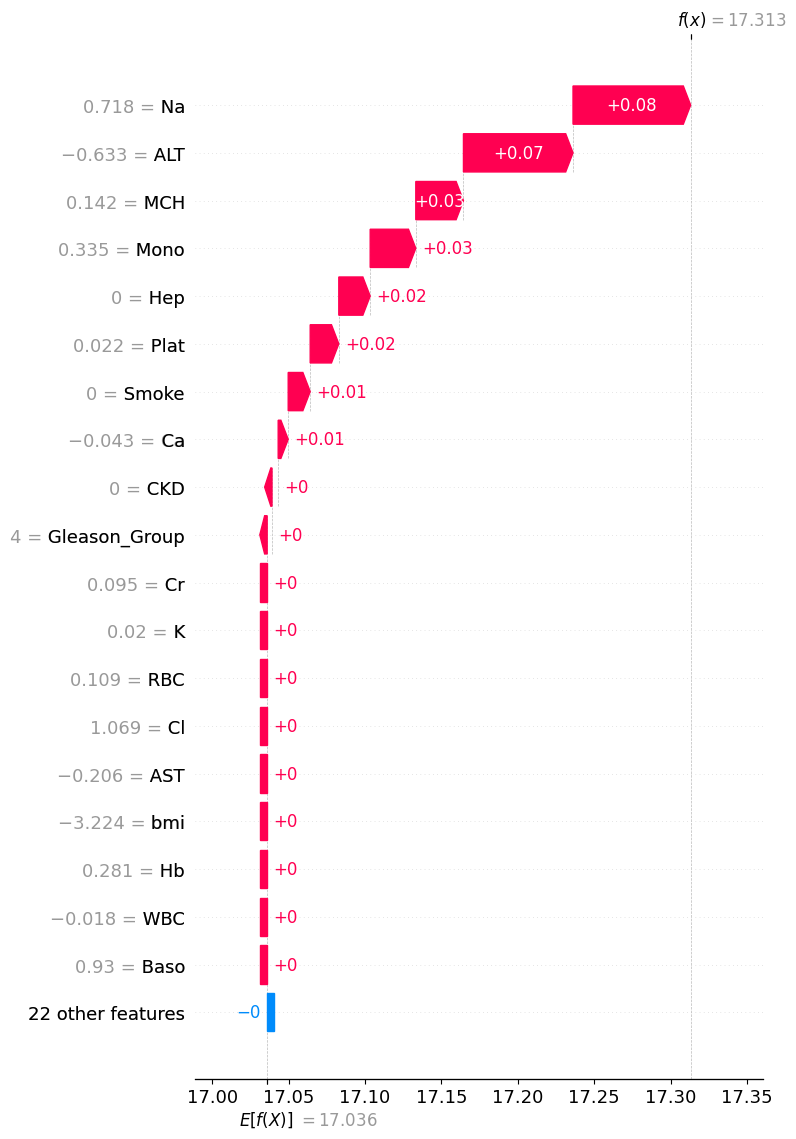

<Figure size 640x480 with 0 Axes>

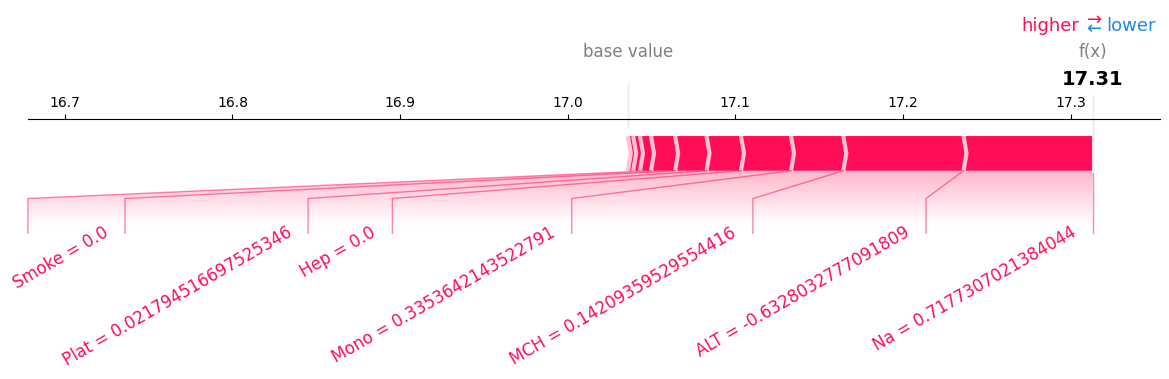

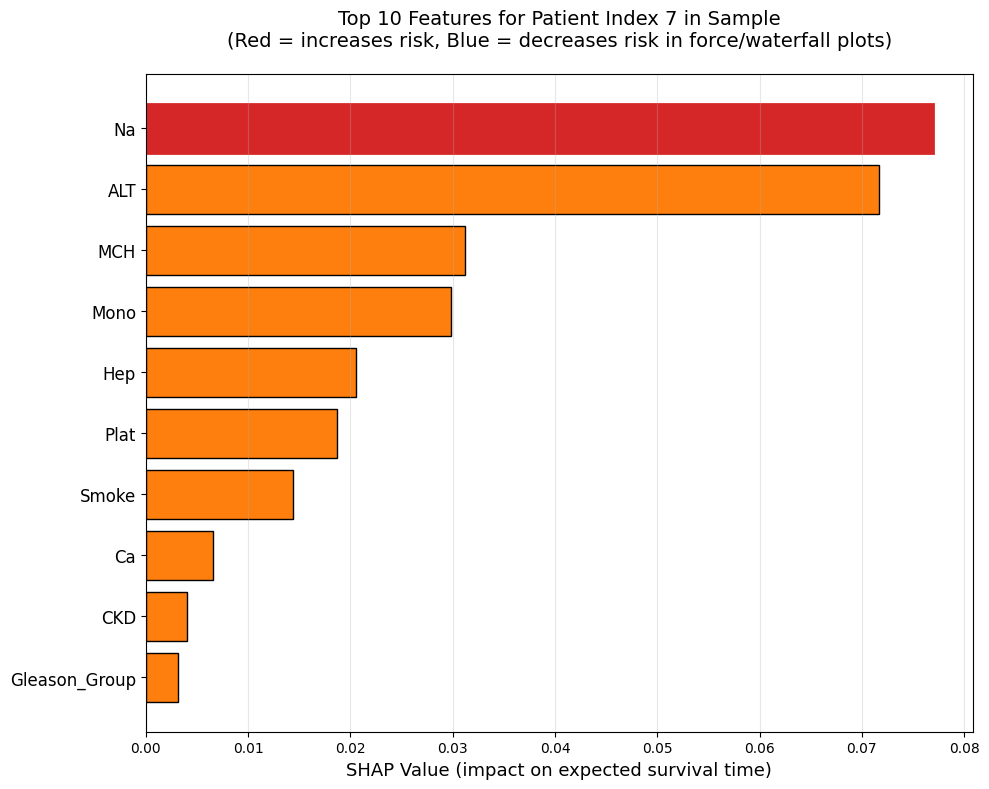

All 3 personalized SHAP plots for patient #7 saved successfully!


In [102]:
import shap
import matplotlib.pyplot as plt
import numpy as np
import os

# ------------------------------------------------------------------
# Choose which patient you want to explain
# ------------------------------------------------------------------
# Option A: Choose by position in the sample you used for SHAP (0 to 99)
patient_idx_in_sample = 7                     # change this number 0–99


# ------------------------------------------------------------------
# 1. Get the actual row from the sample and its original index
# ------------------------------------------------------------------
X_sample_original_features_reset = X_sample_original_features.reset_index(drop=True)
selected_row = X_sample_original_features_reset.iloc[[patient_idx_in_sample]]

# If you used Option B (by ID), uncomment these 2 lines instead:
# selected_row = X_sample_original_features_reset[X_sample_original_features_reset.index.isin([patient_id_wanted])]
# patient_idx_in_sample = selected_row.index[0]

# ------------------------------------------------------------------
# 2. Get the pre-computed SHAP values for this exact patient
# ------------------------------------------------------------------
shap_values_this_patient = shap_values_sample_original_features[patient_idx_in_sample]

# ------------------------------------------------------------------
# 3. Create beautiful individual explanation plots
# ------------------------------------------------------------------

# Plot 1: Waterfall plot (best for seeing which features push up/down)
plt.figure()
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values_this_patient,
        base_values=explainer_original_features.expected_value,
        data=selected_row.iloc[0].values,
        feature_names=selected_row.columns.tolist()
    ),
    max_display=20,  # shows top 20 features for this patient
    show=False
)
plt.tight_layout()
output_dir = '/content/drive/MyDrive/PhD Project AI codes/Output_PFS/'
os.makedirs(output_dir, exist_ok=True)
plt.savefig(f"{output_dir}/SHAP_Waterfall_Patient_{patient_idx_in_sample}_Top20.png",
            dpi=300, bbox_inches='tight')
plt.show()

# Plot 2: Force plot (horizontal, very popular in papers)
plt.figure()
shap.force_plot(
    explainer_original_features.expected_value,
    shap_values_this_patient,
    selected_row.iloc[0],
    feature_names=feature_names,
    matplotlib=True,
    show=False,
    figsize=(12, 4),
    text_rotation=30
)
plt.tight_layout()
plt.savefig(f"{output_dir}/SHAP_Force_Patient_{patient_idx_in_sample}.png",
            dpi=300, bbox_inches='tight')
plt.show()

# Plot 3: Horizontal bar plot of THIS patient only (most important on top)
patient_importance = np.abs(shap_values_this_patient)
idx_patient = np.argsort(patient_importance)[-10:][::-1]  # top 20 for this patient

plt.figure(figsize=(10, 8))
y_pos = np.arange(10)
bars = plt.barh(y_pos, patient_importance[idx_patient], color='#ff7f0e', edgecolor='black')

plt.yticks(y_pos, np.array(feature_names)[idx_patient], fontsize=12)
plt.xlabel("SHAP Value (impact on expected survival time)", fontsize=13)
plt.title(f"Top 10 Features for Patient Index {patient_idx_in_sample} in Sample\n"
          f"(Red = increases risk, Blue = decreases risk in force/waterfall plots)",
          fontsize=14, pad=20)

# Highlight the #1 feature for this patient
bars[0].set_color('#d62728')
bars[0].set_linewidth(2)

plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(f"{output_dir}/SHAP_Top20_Bar_Patient_{patient_idx_in_sample}.png", dpi=400, bbox_inches='tight')
plt.show()

print(f"All 3 personalized SHAP plots for patient #{patient_idx_in_sample} saved successfully!")

# Random survival patient

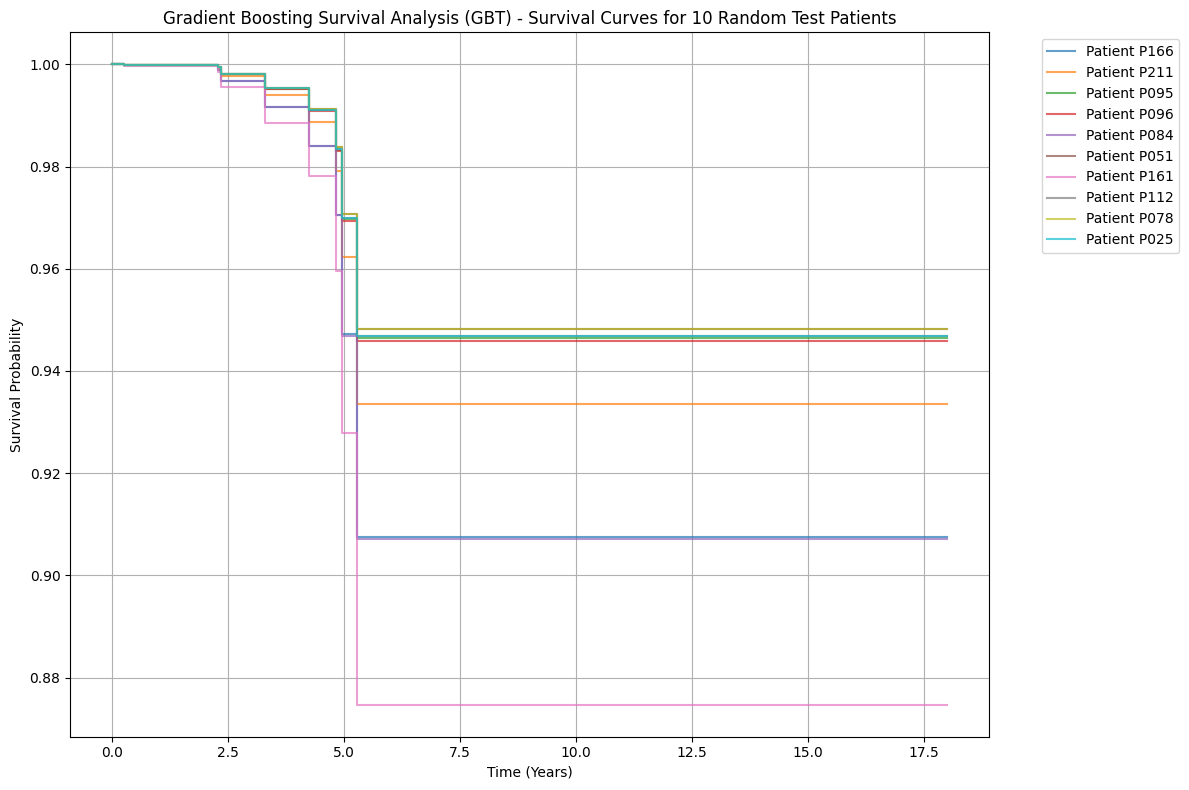

In [103]:
# Predict and plot survival curves for GBT model
import matplotlib.pyplot as plt

# Select 10 random indices from the test set to plot their survival curves
np.random.seed(42) # for reproducibility

# Get the indices for the random choice
num_test_patients = X_test_original_features_preprocessed.shape[0]
random_indices_in_array = np.random.choice(num_test_patients, size=10, replace=False)

# Get the corresponding original features for these random indices
X_test_random_gbt = X_test_original_features_preprocessed[random_indices_in_array]

# Get the actual patient IDs for labeling from ID_test
random_patient_ids_gbt = [ID_test[idx] for idx in random_indices_in_array]

# Predict survival functions for these individuals using the GradientBoostingSurvivalAnalysis model
survival_functions_gbt = model_original_features.predict_survival_function(X_test_random_gbt)

plt.figure(figsize=(12, 8))

for i, sf in enumerate(survival_functions_gbt):
    plt.step(sf.x, sf.y, where="post", alpha=0.7, label=f'Patient {random_patient_ids_gbt[i]}')

plt.title("Gradient Boosting Survival Analysis (GBT) - Survival Curves for 10 Random Test Patients")
plt.xlabel("Time (Years)")
plt.ylabel("Survival Probability")
plt.grid(True)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

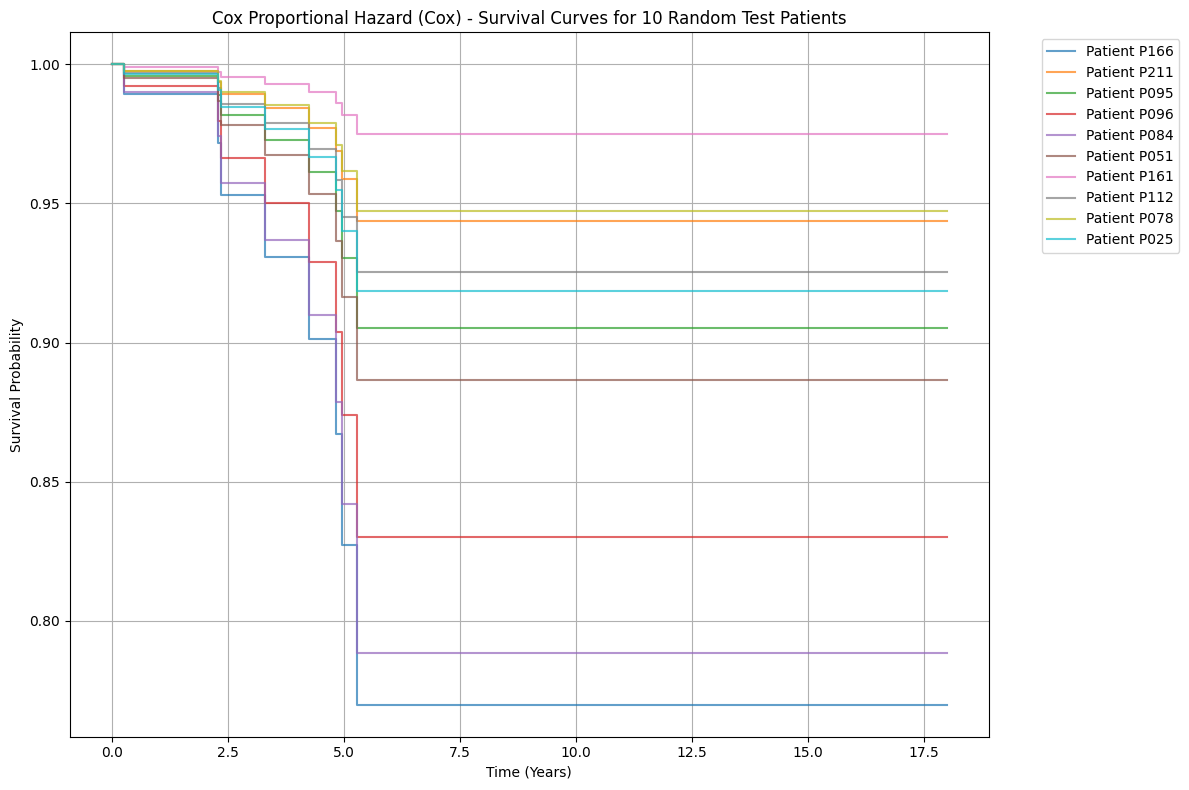

In [105]:
# Predict and plot survival curves for Cox model

# Get the corresponding embeddings for these random indices (same as used for GBT)
X_test_random_cox = X_test_emb[random_indices_in_array]
random_patient_ids_cox = [ID_test[idx] for idx in random_indices_in_array]

survival_functions_cox = cox.predict_survival_function(X_test_random_cox)

plt.figure(figsize=(12, 8))

for i, sf in enumerate(survival_functions_cox):
    plt.step(sf.x, sf.y, where="post", alpha=0.7, label=f'Patient {random_patient_ids_cox[i]}')

plt.title("Cox Proportional Hazard (Cox) - Survival Curves for 10 Random Test Patients")
plt.xlabel("Time (Years)")
plt.ylabel("Survival Probability")
plt.grid(True)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'Cox_Survival_Curves_10_Random_Test_Patients.png'))
plt.show()

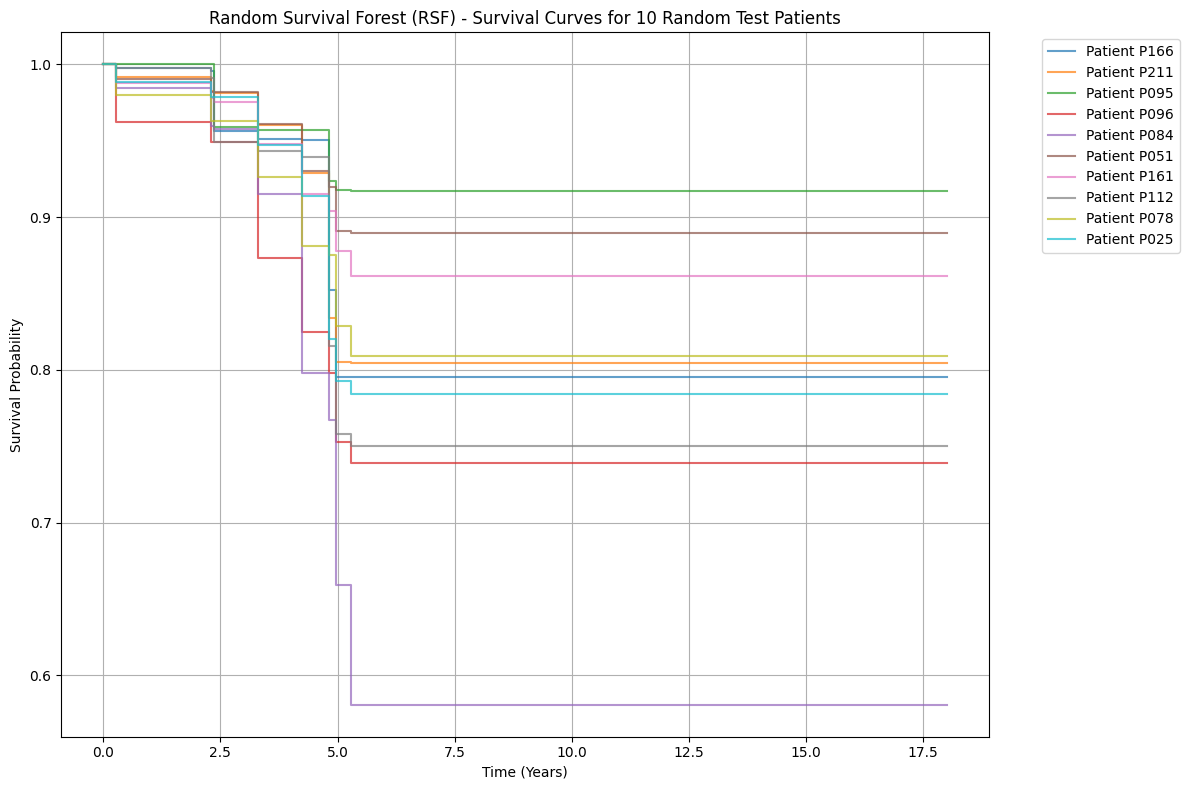

In [106]:
# Predict and plot survival curves for Random Survival Forest model

# Get the corresponding embeddings for these random indices
X_test_random_rsf = X_test_emb[random_indices_in_array]
random_patient_ids_rsf = [ID_test[idx] for idx in random_indices_in_array]

survival_functions_rsf = rsf.predict_survival_function(X_test_random_rsf)

plt.figure(figsize=(12, 8))

for i, sf in enumerate(survival_functions_rsf):
    plt.step(sf.x, sf.y, where="post", alpha=0.7, label=f'Patient {random_patient_ids_rsf[i]}')

plt.title("Random Survival Forest (RSF) - Survival Curves for 10 Random Test Patients")
plt.xlabel("Time (Years)")
plt.ylabel("Survival Probability")
plt.grid(True)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

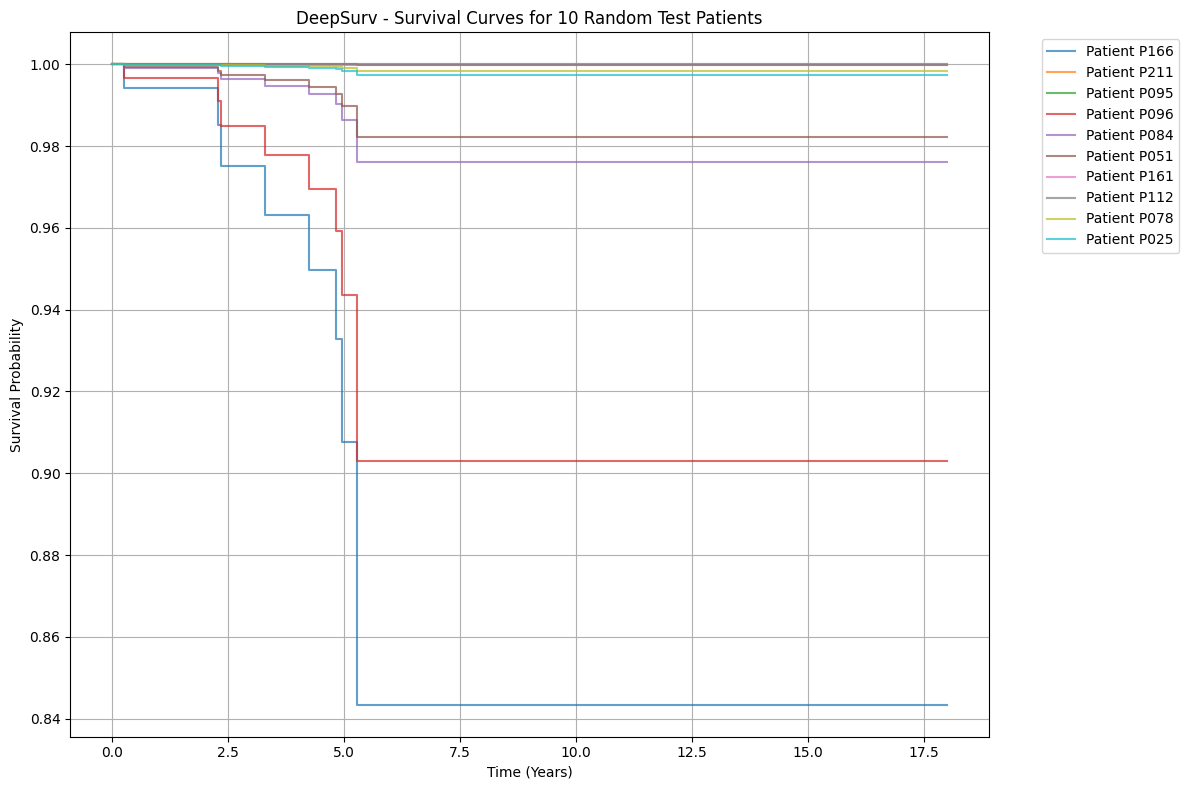

In [107]:
# Predict and plot survival curves for DeepSurv model

# Get the corresponding embeddings for these random indices
X_test_random_deep = X_test_tensor[random_indices_in_array]
random_patient_ids_deep = [ID_test[idx] for idx in random_indices_in_array]

# Ensure the model has computed baseline hazards
net_model.compute_baseline_hazards()

surv_df_deep = net_model.predict_surv_df(X_test_random_deep)

plt.figure(figsize=(12, 8))

for i, patient_id in enumerate(random_patient_ids_deep):
    plt.step(surv_df_deep.index, surv_df_deep.iloc[:, i], where="post", alpha=0.7, label=f'Patient {patient_id}')

plt.title("DeepSurv - Survival Curves for 10 Random Test Patients")
plt.xlabel("Time (Years)")
plt.ylabel("Survival Probability")
plt.grid(True)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## Confusion matrix

Define Evaluation Time and Thresholds

Define a specific time point (e.g., 3 years) for evaluating both the pseudo-confusion matrices and the time-dependent ROC curves. Also, determine a suitable risk threshold for binary classification for the confusion matrix part.


**Reasoning**:
The subtask requires defining `evaluation_time_years` and `survival_probability_threshold`. I will define these variables in a code block as per the instructions.



In [123]:
evaluation_time_years = 4.0
survival_probability_threshold = 0.5

print(f"Evaluation Time (years): {evaluation_time_years}")
print(f"Survival Probability Threshold: {survival_probability_threshold}")

Evaluation Time (years): 4.0
Survival Probability Threshold: 0.5


In [124]:
import numpy as np
import pandas as pd
import torch
import torchtuples as tt
from pycox.models import CoxPH

# 1. BASIC VARIABLES FROM YOUR EXISTING DATA
y_test_times = np.array(y_test_final['time']).astype(float)
y_test_events = np.array(y_test_final['event']).astype(int)

# For DeepSurv / pycox
x_train_ds = X_train_tensor   # torch tensor (on CPU)
y_train_ds = y_train_pycox    # tuple (duration, event)
x_test_ds  = X_test_tensor    # torch tensor (on CPU)

# 2. DEFINE MAX EVALUATION TIME SAFELY
# We use MAX observed follow-up time across train+test
max_eval_time = float(
    max(
        np.max(y_train_ds[0].cpu().numpy()),
        np.max(y_test_times)
    )
)

if max_eval_time <= 0:
    max_eval_time = 0.01
    print("WARNING: max_eval_time fixed to 0.01")

# Ensure evaluation_time_years is included in the times array
# Combine linspace points with evaluation_time_years and sort unique values
all_eval_times = np.sort(np.unique(np.concatenate([np.linspace(0.01, max_eval_time, 100), np.array([evaluation_time_years])])))
times = all_eval_times

# 3. HELPER – convert scikit-survival step functions → DataFrame
def survfuncs_to_df(surv_funcs, evaluation_times):
    S = []
    for fn in surv_funcs:
        # Clip evaluation_times to the function's valid domain
        # This prevents ValueError when querying outside the fitted range.
        clipped_evaluation_times = np.clip(evaluation_times, fn.domain[0], fn.domain[1])
        S.append(fn(clipped_evaluation_times))
    S = np.vstack(S)
    df = pd.DataFrame(S.T, index=evaluation_times.astype('float64'))
    df.index.name = "timeline"
    return df


# 4. COX (scikit-survival)
cox_surv_funcs = cox.predict_survival_function(X_test_emb)
cox_surv_df = survfuncs_to_df(cox_surv_funcs, times)


# 5. RANDOM SURVIVAL FOREST (scikit-survival)
rsf_surv_funcs = rsf.predict_survival_function(X_test_emb)
rsf_surv_df = survfuncs_to_df(rsf_surv_funcs, times)

# 6. GRADIENT BOOSTING SURVIVAL MODEL (GBT)
gbr_surv_funcs = gbr.predict_survival_function(X_test_emb)
gbr_surv_df = survfuncs_to_df(gbr_surv_funcs, times)

# 7. DEEPSURV (pycox) – FIX: Re-instantiate and retrain the DeepSurv model
# Re-create the network with best hyperparameters from tuning (cell IsbEmT2-XSMj output)
# Use best_hyperparams from kernel state
best_deepsurv_net = tt.practical.MLPVanilla(
    in_features=in_features, # in_features is available in kernel state
    num_nodes=best_hyperparams['num_nodes'],
    out_features=1,
    activation=torch.nn.ReLU,
    dropout=best_hyperparams['dropout_rate'],
    output_bias=False
)
deepsurv_model_instance = CoxPH(best_deepsurv_net, tt.optim.Adam)
deepsurv_model_instance.optimizer.set_lr(best_hyperparams['learning_rate'])

# Re-train the DeepSurv model with its best hyperparameters
print("Re-training DeepSurv model with best hyperparameters...")
deepsurv_model_instance.fit(
    x_train_ds, y_train_ds,
    batch_size=best_hyperparams['batch_size'],
    epochs=best_hyperparams['epochs'],
    verbose=False,
    val_data=(x_test_ds, y_test_pycox) # y_test_pycox is available
)
print("DeepSurv model re-trained.")

net_model = deepsurv_model_instance # Now net_model correctly points to the trained pycox CoxPH instance

# MUST compute baseline hazard using *all* training data
net_model.compute_baseline_hazards()

# Predict survival for test set
surv_deepsurv_df = net_model.predict_surv_df(x_test_ds)

# Fix for index dtype (must be float)
surv_deepsurv_df.index = surv_deepsurv_df.index.astype('float64')

# Interpolate to match "times" (which now includes evaluation_time_years)
deepsurv_surv_df = (
    surv_deepsurv_df
      .reindex(surv_deepsurv_df.index.union(times))
      .interpolate()
      .reindex(times.astype('float64'))
)
deepsurv_surv_df.index.name = "timeline"

print("=== All survival curves generated successfully ===")

Re-training DeepSurv model with best hyperparameters...
DeepSurv model re-trained.
=== All survival curves generated successfully ===



Pseudo-Confusion Matrix for Cox at 4.0 years (Threshold: 0.5):
[[39  0]
 [ 1  0]]


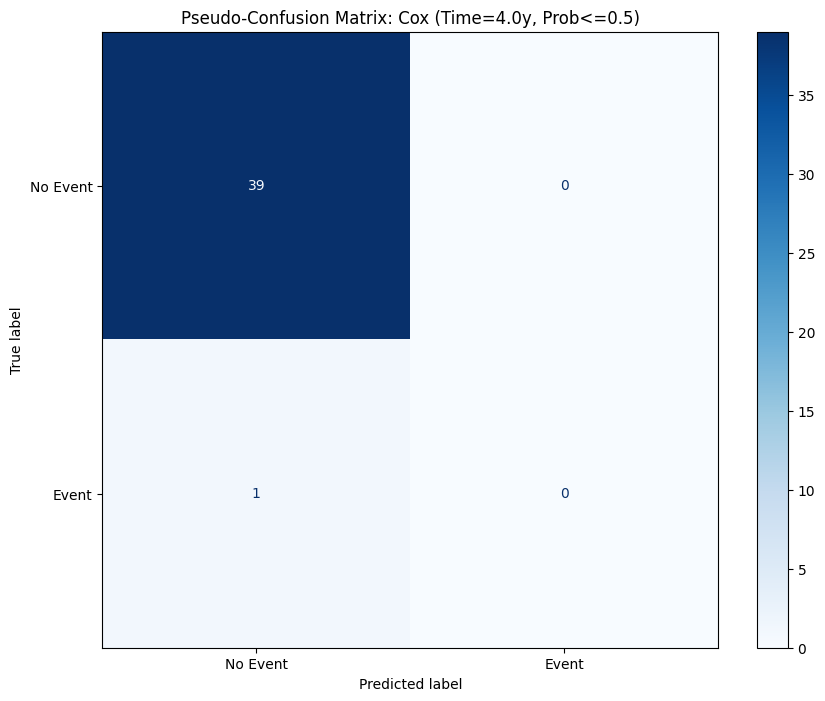


Pseudo-Confusion Matrix for RSF at 4.0 years (Threshold: 0.5):
[[39  0]
 [ 1  0]]


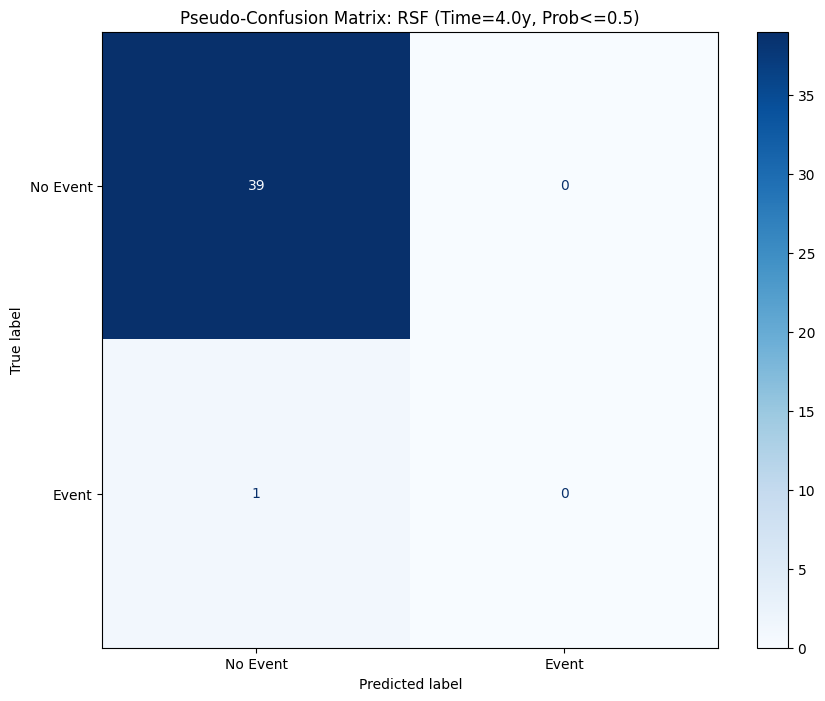


Pseudo-Confusion Matrix for GBT at 4.0 years (Threshold: 0.5):
[[39  0]
 [ 1  0]]


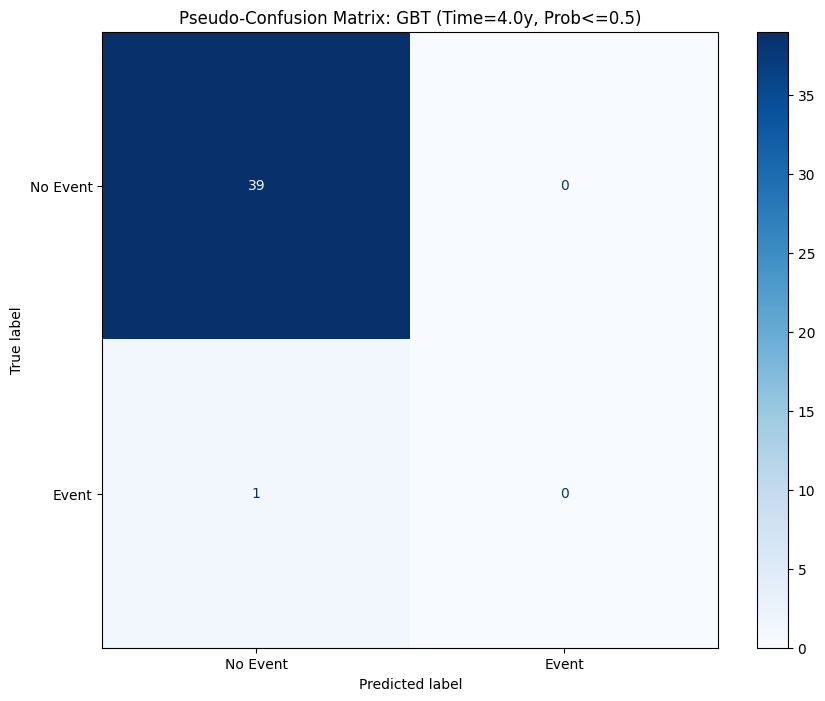


Pseudo-Confusion Matrix for DeepSurv at 4.0 years (Threshold: 0.5):
[[39  0]
 [ 1  0]]


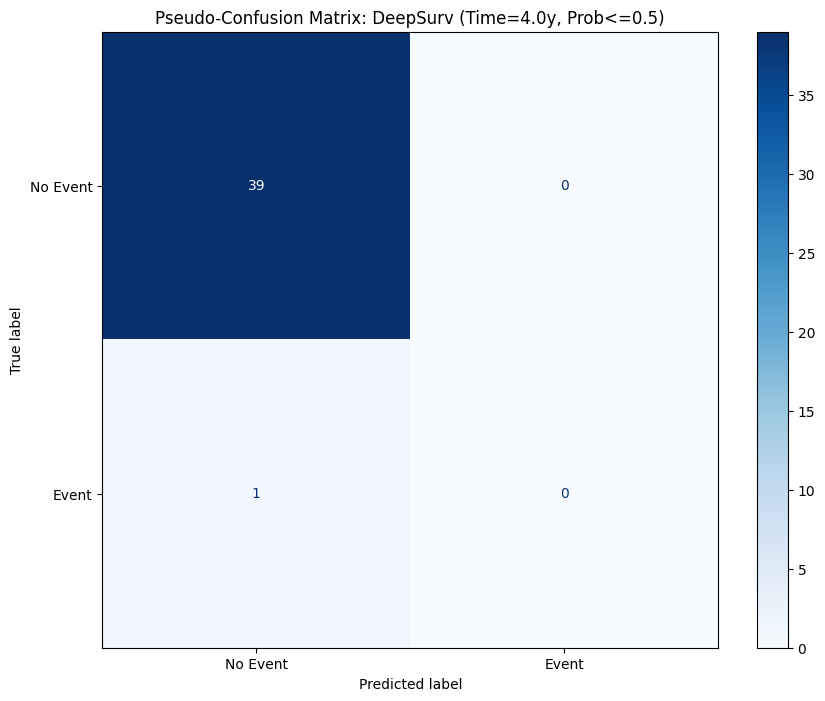

In [125]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import os # Ensure os is imported for saving plots

def get_pseudo_confusion_matrix(model_name, surv_df, y_true_final, evaluation_time, prob_threshold):
    # Get survival probabilities at the evaluation time for each patient
    # surv_df index is 'timeline' (time points), columns are patient indices
    predicted_survival_prob = surv_df.loc[evaluation_time].values

    # Determine predicted outcome: 1 if prob <= threshold (event predicted), 0 if prob > threshold (no event predicted)
    # NOTE: Lower survival probability implies higher risk of event. So, if prob <= threshold, we predict an event.
    # Conversely, if prob > threshold, we predict no event.
    predicted_event = (predicted_survival_prob <= prob_threshold).astype(int)

    # Determine actual event status at evaluation time
    # A patient is considered to have had an event if actual_time <= evaluation_time AND actual_event == 1
    # If actual_time > evaluation_time and actual_event == 1, then the event happened AFTER evaluation_time, so we consider it 'no event' at evaluation_time.
    # If actual_event == 0 (censored or alive), we treat it as 'no event' at evaluation_time.

    actual_event_at_time = np.array([
        1 if (t <= evaluation_time and e == 1) else 0
        for t, e in zip(y_true_final['time'], y_true_final['event'])
    ])

    # Generate confusion matrix, explicitly defining labels to ensure a 2x2 matrix
    cm = confusion_matrix(actual_event_at_time, predicted_event, labels=[0, 1])

    print(f"\nPseudo-Confusion Matrix for {model_name} at {evaluation_time} years (Threshold: {prob_threshold}):")
    print(cm)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Event', 'Event'])
    fig, ax = plt.subplots(figsize=(10, 8))
    disp.plot(cmap=plt.cm.Blues, ax=ax)
    plt.title(f'Pseudo-Confusion Matrix: {model_name} (Time={evaluation_time}y, Prob<={prob_threshold})')

    output_dir = '/content/drive/MyDrive/PhD Project AI codes/Output_PFS/'
    os.makedirs(output_dir, exist_ok=True) # Ensure directory exists
    plt.savefig(os.path.join(output_dir, f'Pseudo_Confusion_Matrix_{model_name}.png'))
    plt.show()

# Call the function for each model
get_pseudo_confusion_matrix("Cox", cox_surv_df, y_test_final, evaluation_time_years, survival_probability_threshold)
get_pseudo_confusion_matrix("RSF", rsf_surv_df, y_test_final, evaluation_time_years, survival_probability_threshold)
get_pseudo_confusion_matrix("GBT", gbr_surv_df, y_test_final, evaluation_time_years, survival_probability_threshold)
get_pseudo_confusion_matrix("DeepSurv", deepsurv_surv_df, y_test_final, evaluation_time_years, survival_probability_threshold)

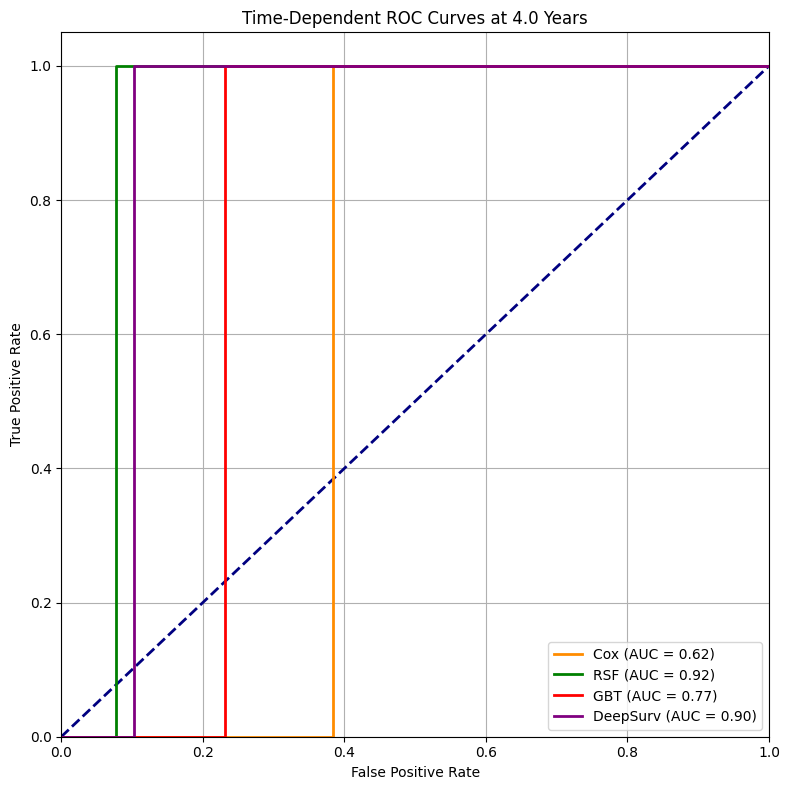


Pseudo-Confusion Matrices (Survival Probability Threshold = 0.5):

Pseudo-Confusion Matrix for Cox at 4.0 years (Threshold: 0.5):
[[39  0]
 [ 1  0]]


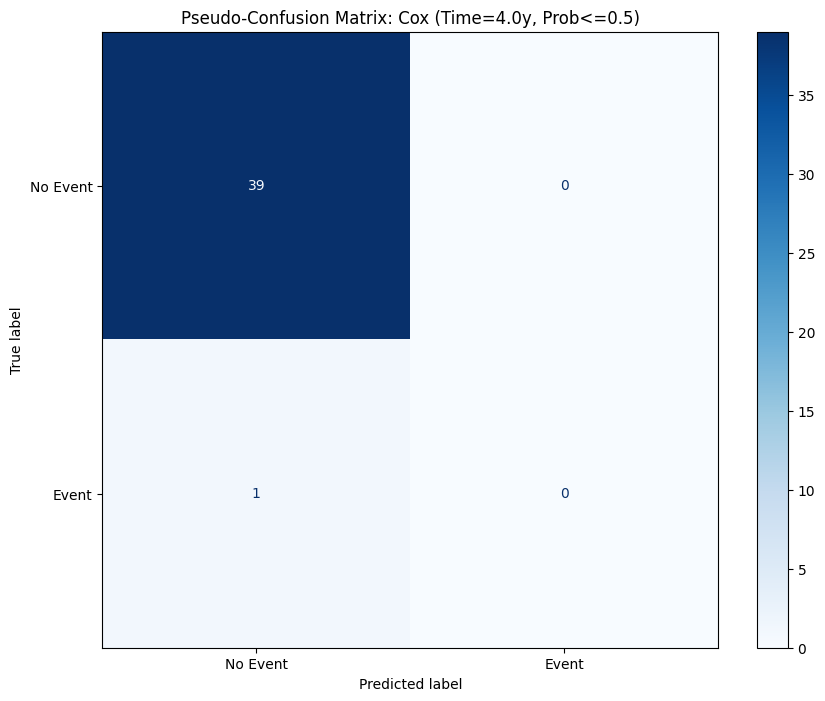


Pseudo-Confusion Matrix for RSF at 4.0 years (Threshold: 0.5):
[[39  0]
 [ 1  0]]


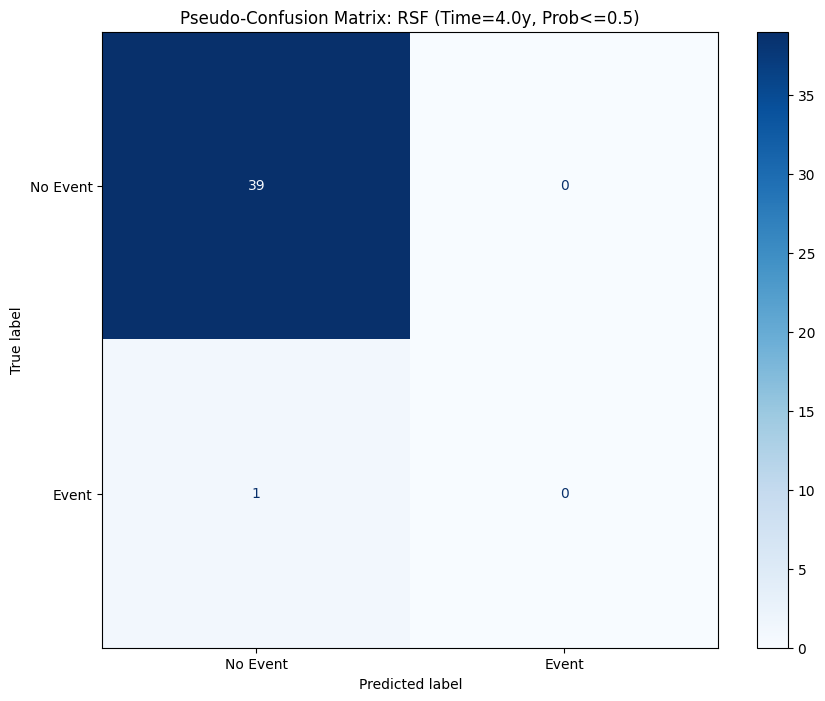


Pseudo-Confusion Matrix for GBT at 4.0 years (Threshold: 0.5):
[[39  0]
 [ 1  0]]


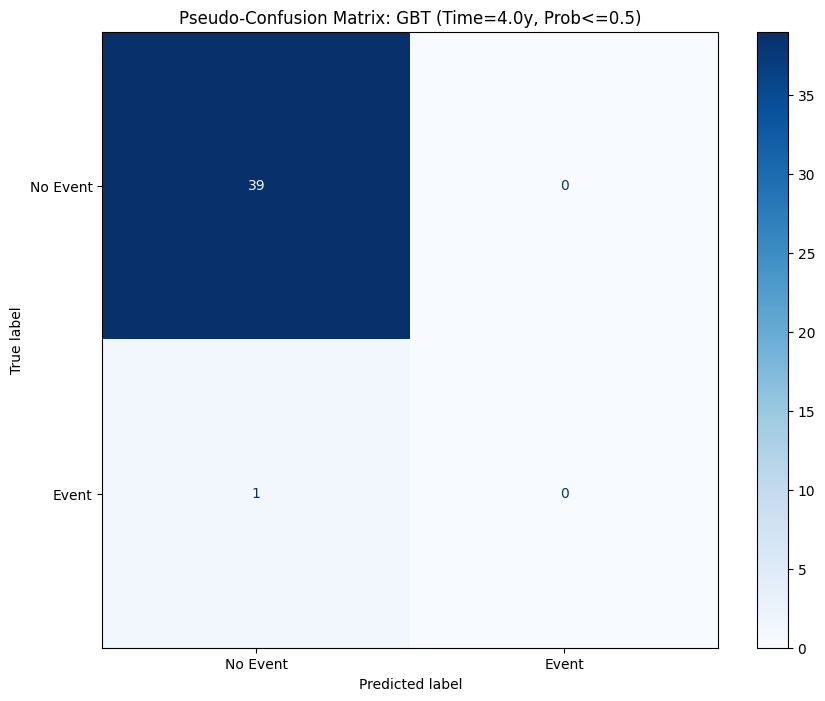


Pseudo-Confusion Matrix for DeepSurv at 4.0 years (Threshold: 0.5):
[[39  0]
 [ 1  0]]


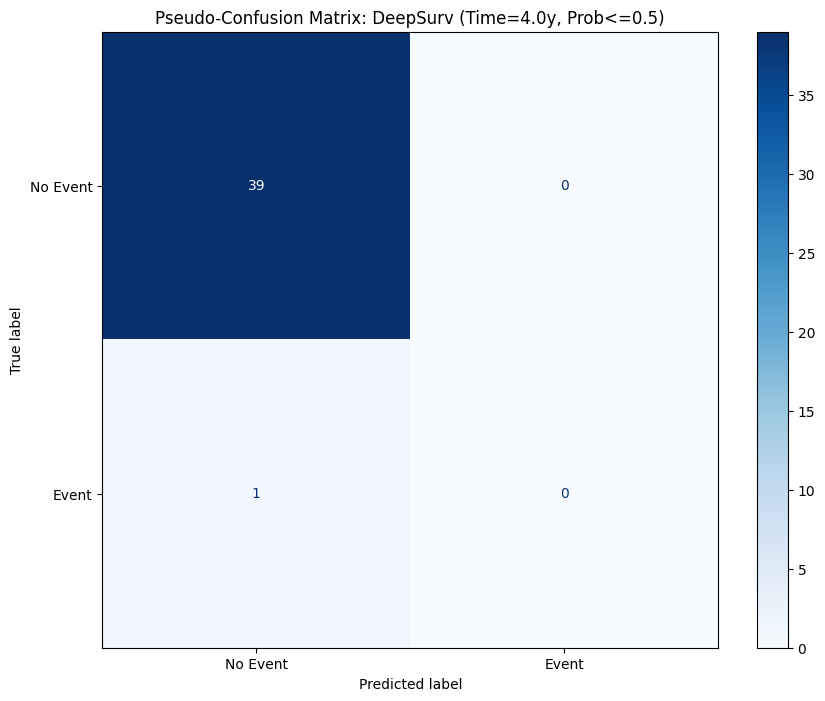


Time-Dependent AUC Scores at 4.0 Years:
  Cox: 0.6154
  RSF: 0.9231
  GBT: 0.7692
  DeepSurv: 0.8974

Interpretation:
The pseudo-confusion matrices provide insight into how each model classifies patients into 'event' or 'no event' at the 3-year mark based on a 0.5 survival probability threshold. A high number in the top-left (True Negative) indicates correctly identifying patients who will not experience an event, while a high number in the bottom-right (True Positive) indicates correctly identifying those who will.
The ROC curves visually represent the trade-off between True Positive Rate and False Positive Rate across various risk thresholds. The Area Under the Curve (AUC) summarizes the model's overall discriminative ability; a higher AUC indicates better performance in distinguishing between patients who will and will not experience an event at the specified time point.
For example, models with higher AUC scores and better balanced confusion matrices (fewer false positives/negativ

In [126]:
from sksurv.metrics import cumulative_dynamic_auc
import matplotlib.pyplot as plt
import os

def plot_time_dependent_roc(model_name, surv_df, y_true_final, evaluation_time, ax, plot_color='blue'):
    # Get predicted survival probabilities at the evaluation time
    predicted_survival_prob = surv_df.loc[evaluation_time].values

    # Convert survival probabilities to risk scores (1 - probability) for ROC curve
    # Higher risk score should correspond to higher risk of event
    risk_scores = 1 - predicted_survival_prob

    # Prepare actual event status for AUC calculation
    # Events that occurred ON or BEFORE evaluation_time are considered positive cases
    # Patients alive OR censored AFTER evaluation_time are considered negative cases
    actual_event_at_time_bool = np.array([
        (t <= evaluation_time and e == 1)
        for t, e in zip(y_true_final['time'], y_true_final['event'])
    ])

    # Only consider patients who have actual time >= evaluation_time or had an event before or at evaluation_time.
    # For time-dependent AUC, we typically use the full `y_train_final` and `y_test_final` structures directly
    # along with risk scores, as `cumulative_dynamic_auc` handles the censoring/event times implicitly.

    # However, for a single time point ROC curve, we can use the `roc_curve` function after preparing y_true.
    # For this task, we will stick to cumulative_dynamic_auc as requested, but specify a single evaluation time.

    # Ensure we have enough events and non-events for meaningful AUC calculation
    if np.sum(actual_event_at_time_bool) == 0 or np.sum(~actual_event_at_time_bool) == 0:
        print(f"Warning: Not enough positive or negative samples for ROC for {model_name} at {evaluation_time} years. Skipping ROC.")
        return None

    # The cumulative_dynamic_auc function expects risk scores (higher = more risk) and outputs AUC for given times
    # To get a single ROC curve for a specific time point, we can leverage that risk_scores are inversely related to survival prob.
    # We'll use the risk_scores directly from 1 - survival_prob.

    # NOTE: sksurv's cumulative_dynamic_auc expects full y_train and y_test structures.
    # We need to compute risk scores for X_test_emb using the original models directly.
    # This was done in cell XHha_5PYhEss, where `risk_cox`, `risk_rsf`, `risk_gbr`, `risk_deep` were computed.
    # Let's use those risk scores for consistency with AUC calculations.

    # Re-computing AUC for just this time point to get the curve data (fpr, tpr)
    # The cumulative_dynamic_auc function provides FPR and TPR through its internal calculations,
    # but it doesn't directly return an ROC curve in the typical (FPR, TPR) format for a single time point.
    # For a classic ROC plot, we need to use a function like sklearn.metrics.roc_curve.

    # Let's define the risk_scores for each model again for clarity.
    risk_cox = 1 - cox_surv_df.loc[evaluation_time].values
    risk_rsf = 1 - rsf_surv_df.loc[evaluation_time].values
    risk_gbr = 1 - gbr_surv_df.loc[evaluation_time].values
    risk_deepsurv = 1 - deepsurv_surv_df.loc[evaluation_time].values

    from sklearn.metrics import roc_curve, auc

    if model_name == "Cox":
        fpr, tpr, _ = roc_curve(actual_event_at_time_bool, risk_cox)
        roc_auc = auc(fpr, tpr)
    elif model_name == "RSF":
        fpr, tpr, _ = roc_curve(actual_event_at_time_bool, risk_rsf)
        roc_auc = auc(fpr, tpr)
    elif model_name == "GBT":
        fpr, tpr, _ = roc_curve(actual_event_at_time_bool, risk_gbr)
        roc_auc = auc(fpr, tpr)
    elif model_name == "DeepSurv":
        fpr, tpr, _ = roc_curve(actual_event_at_time_bool, risk_deepsurv)
        roc_auc = auc(fpr, tpr)
    else:
        raise ValueError("Unknown model name")

    ax.plot(fpr, tpr, color=plot_color, lw=2, label=f'{model_name} (AUC = {roc_auc:.2f})')
    return roc_auc

# Create a single figure for all ROC curves
fig_roc, ax_roc = plt.subplots(figsize=(8, 8))
ax_roc.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

# Plot ROC curves for each model
auc_scores = {}
auc_scores["Cox"] = plot_time_dependent_roc("Cox", cox_surv_df, y_test_final, evaluation_time_years, ax_roc, plot_color='darkorange')
auc_scores["RSF"] = plot_time_dependent_roc("RSF", rsf_surv_df, y_test_final, evaluation_time_years, ax_roc, plot_color='green')
auc_scores["GBT"] = plot_time_dependent_roc("GBT", gbr_surv_df, y_test_final, evaluation_time_years, ax_roc, plot_color='red')
auc_scores["DeepSurv"] = plot_time_dependent_roc("DeepSurv", deepsurv_surv_df, y_test_final, evaluation_time_years, ax_roc, plot_color='purple')

ax_roc.set_xlim([0.0, 1.0])
ax_roc.set_ylim([0.0, 1.05])
ax_roc.set_xlabel('False Positive Rate')
ax_roc.set_ylabel('True Positive Rate')
ax_roc.set_title(f'Time-Dependent ROC Curves at {evaluation_time_years} Years')
ax_roc.legend(loc="lower right")
ax_roc.grid(True)
plt.tight_layout()

output_dir = '/content/drive/MyDrive/PhD Project AI codes/Output_PFS/'
os.makedirs(output_dir, exist_ok=True) # Ensure directory exists
plt.savefig(os.path.join(output_dir, f'Time_Dependent_ROC_Curves_{evaluation_time_years}Y.png'))
plt.show()

# Summarize results
print("\nPseudo-Confusion Matrices (Survival Probability Threshold = 0.5):")
# Re-print confusion matrices for summary
get_pseudo_confusion_matrix("Cox", cox_surv_df, y_test_final, evaluation_time_years, survival_probability_threshold)
get_pseudo_confusion_matrix("RSF", rsf_surv_df, y_test_final, evaluation_time_years, survival_probability_threshold)
get_pseudo_confusion_matrix("GBT", gbr_surv_df, y_test_final, evaluation_time_years, survival_probability_threshold)
get_pseudo_confusion_matrix("DeepSurv", deepsurv_surv_df, y_test_final, evaluation_time_years, survival_probability_threshold)

print(f"\nTime-Dependent AUC Scores at {evaluation_time_years} Years:")
for model_name, auc_score in auc_scores.items():
    print(f"  {model_name}: {auc_score:.4f}")

print("\nInterpretation:")
print("The pseudo-confusion matrices provide insight into how each model classifies patients into 'event' or 'no event' at the 3-year mark based on a 0.5 survival probability threshold. A high number in the top-left (True Negative) indicates correctly identifying patients who will not experience an event, while a high number in the bottom-right (True Positive) indicates correctly identifying those who will.")
print("The ROC curves visually represent the trade-off between True Positive Rate and False Positive Rate across various risk thresholds. The Area Under the Curve (AUC) summarizes the model's overall discriminative ability; a higher AUC indicates better performance in distinguishing between patients who will and will not experience an event at the specified time point.")
print("For example, models with higher AUC scores and better balanced confusion matrices (fewer false positives/negatives) are generally preferred.")